In [1]:
import scanpy as sc
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import scFates as scf
sc.set_figure_params(dpi=150)

In [2]:
adata=sc.read("/home/matei/data/adata_neuroblastoma_assigned.h5ad")

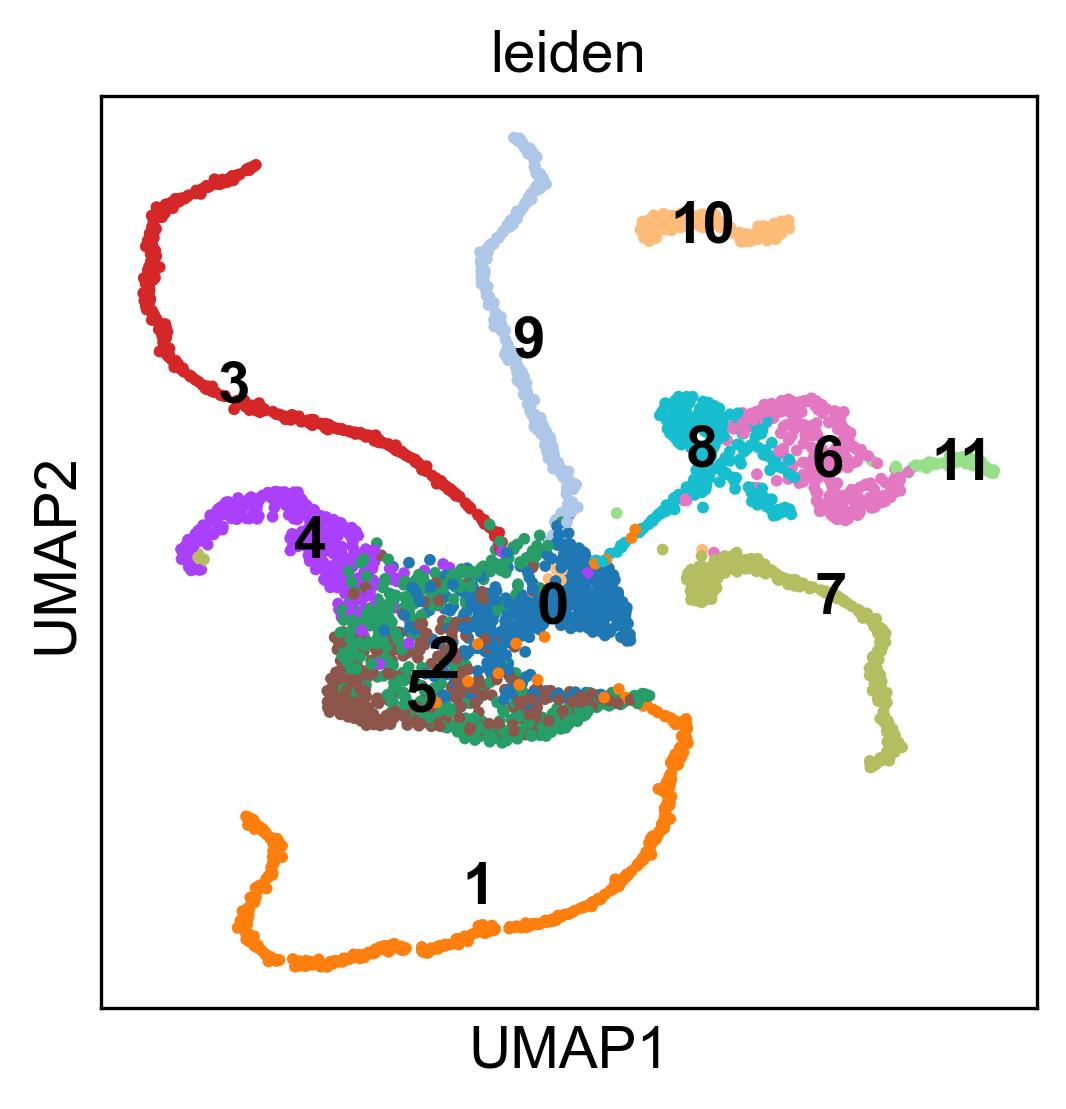

In [3]:
sc.pl.umap(adata,color="leiden",legend_loc="on data")

In [4]:
# Subsetting - removing clusters that are isolated
adata=adata[~adata.obs.leiden.isin(["7","10","11","6","11","8"])]

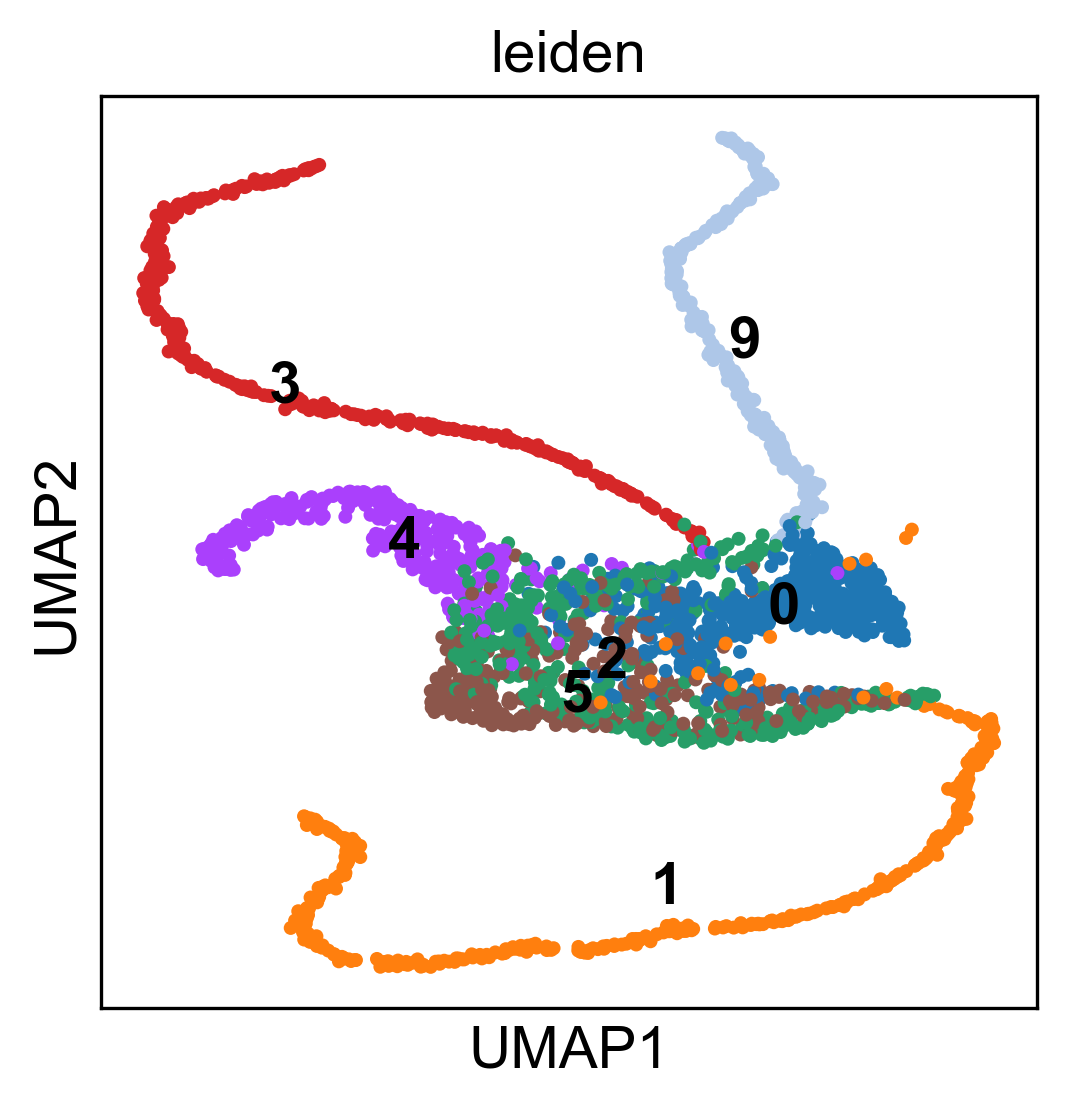

In [5]:
sc.pl.umap(adata,color="leiden",legend_loc="on data")

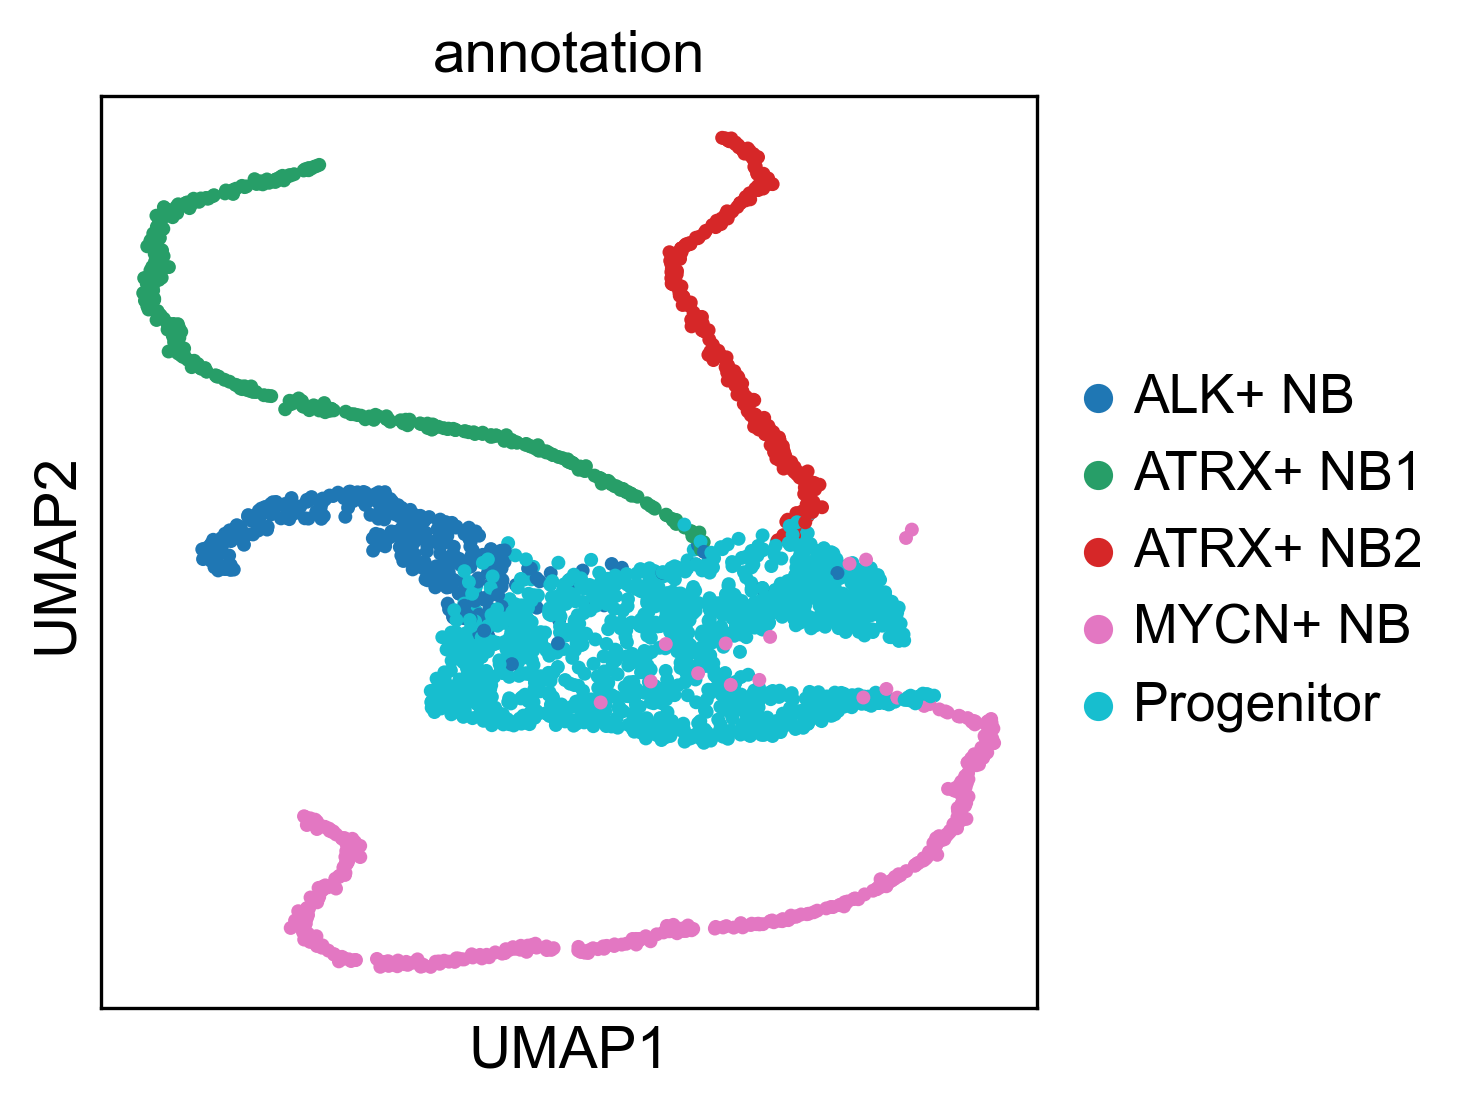

In [6]:
sc.pl.umap(adata,color="annotation")

# Tree inference

In [7]:
adata.shape

(2682, 331361)

In [8]:
scf.tl.tree(adata,Nodes=1000,method="ppt",device="cpu",seed=100,
            use_rep="X_diff",ppt_sigma=.0005,ppt_lambda=200,ppt_nsteps=100)

inferring a principal tree --> parameters used 
    1000 principal points, sigma = 0.0005, lambda = 200, metric = euclidean
    fitting:  64%|██████▍   | 64/100 [01:25<00:48,  1.34s/it]
    converged
    finished (0:01:25) 

/home/matei/anaconda3/envs/neuroblastoma/lib/python3.14/site-packages/scFates/tools/graph_fitting.py:425: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["graph"] = graph


--> added 
    .uns['ppt'], dictionnary containing inferred tree.
    .obsm['X_R'] soft assignment of cells to principal points.
    .uns['graph']['B'] adjacency matrix of the principal points.
    .uns['graph']['F'] coordinates of principal points in representation space.


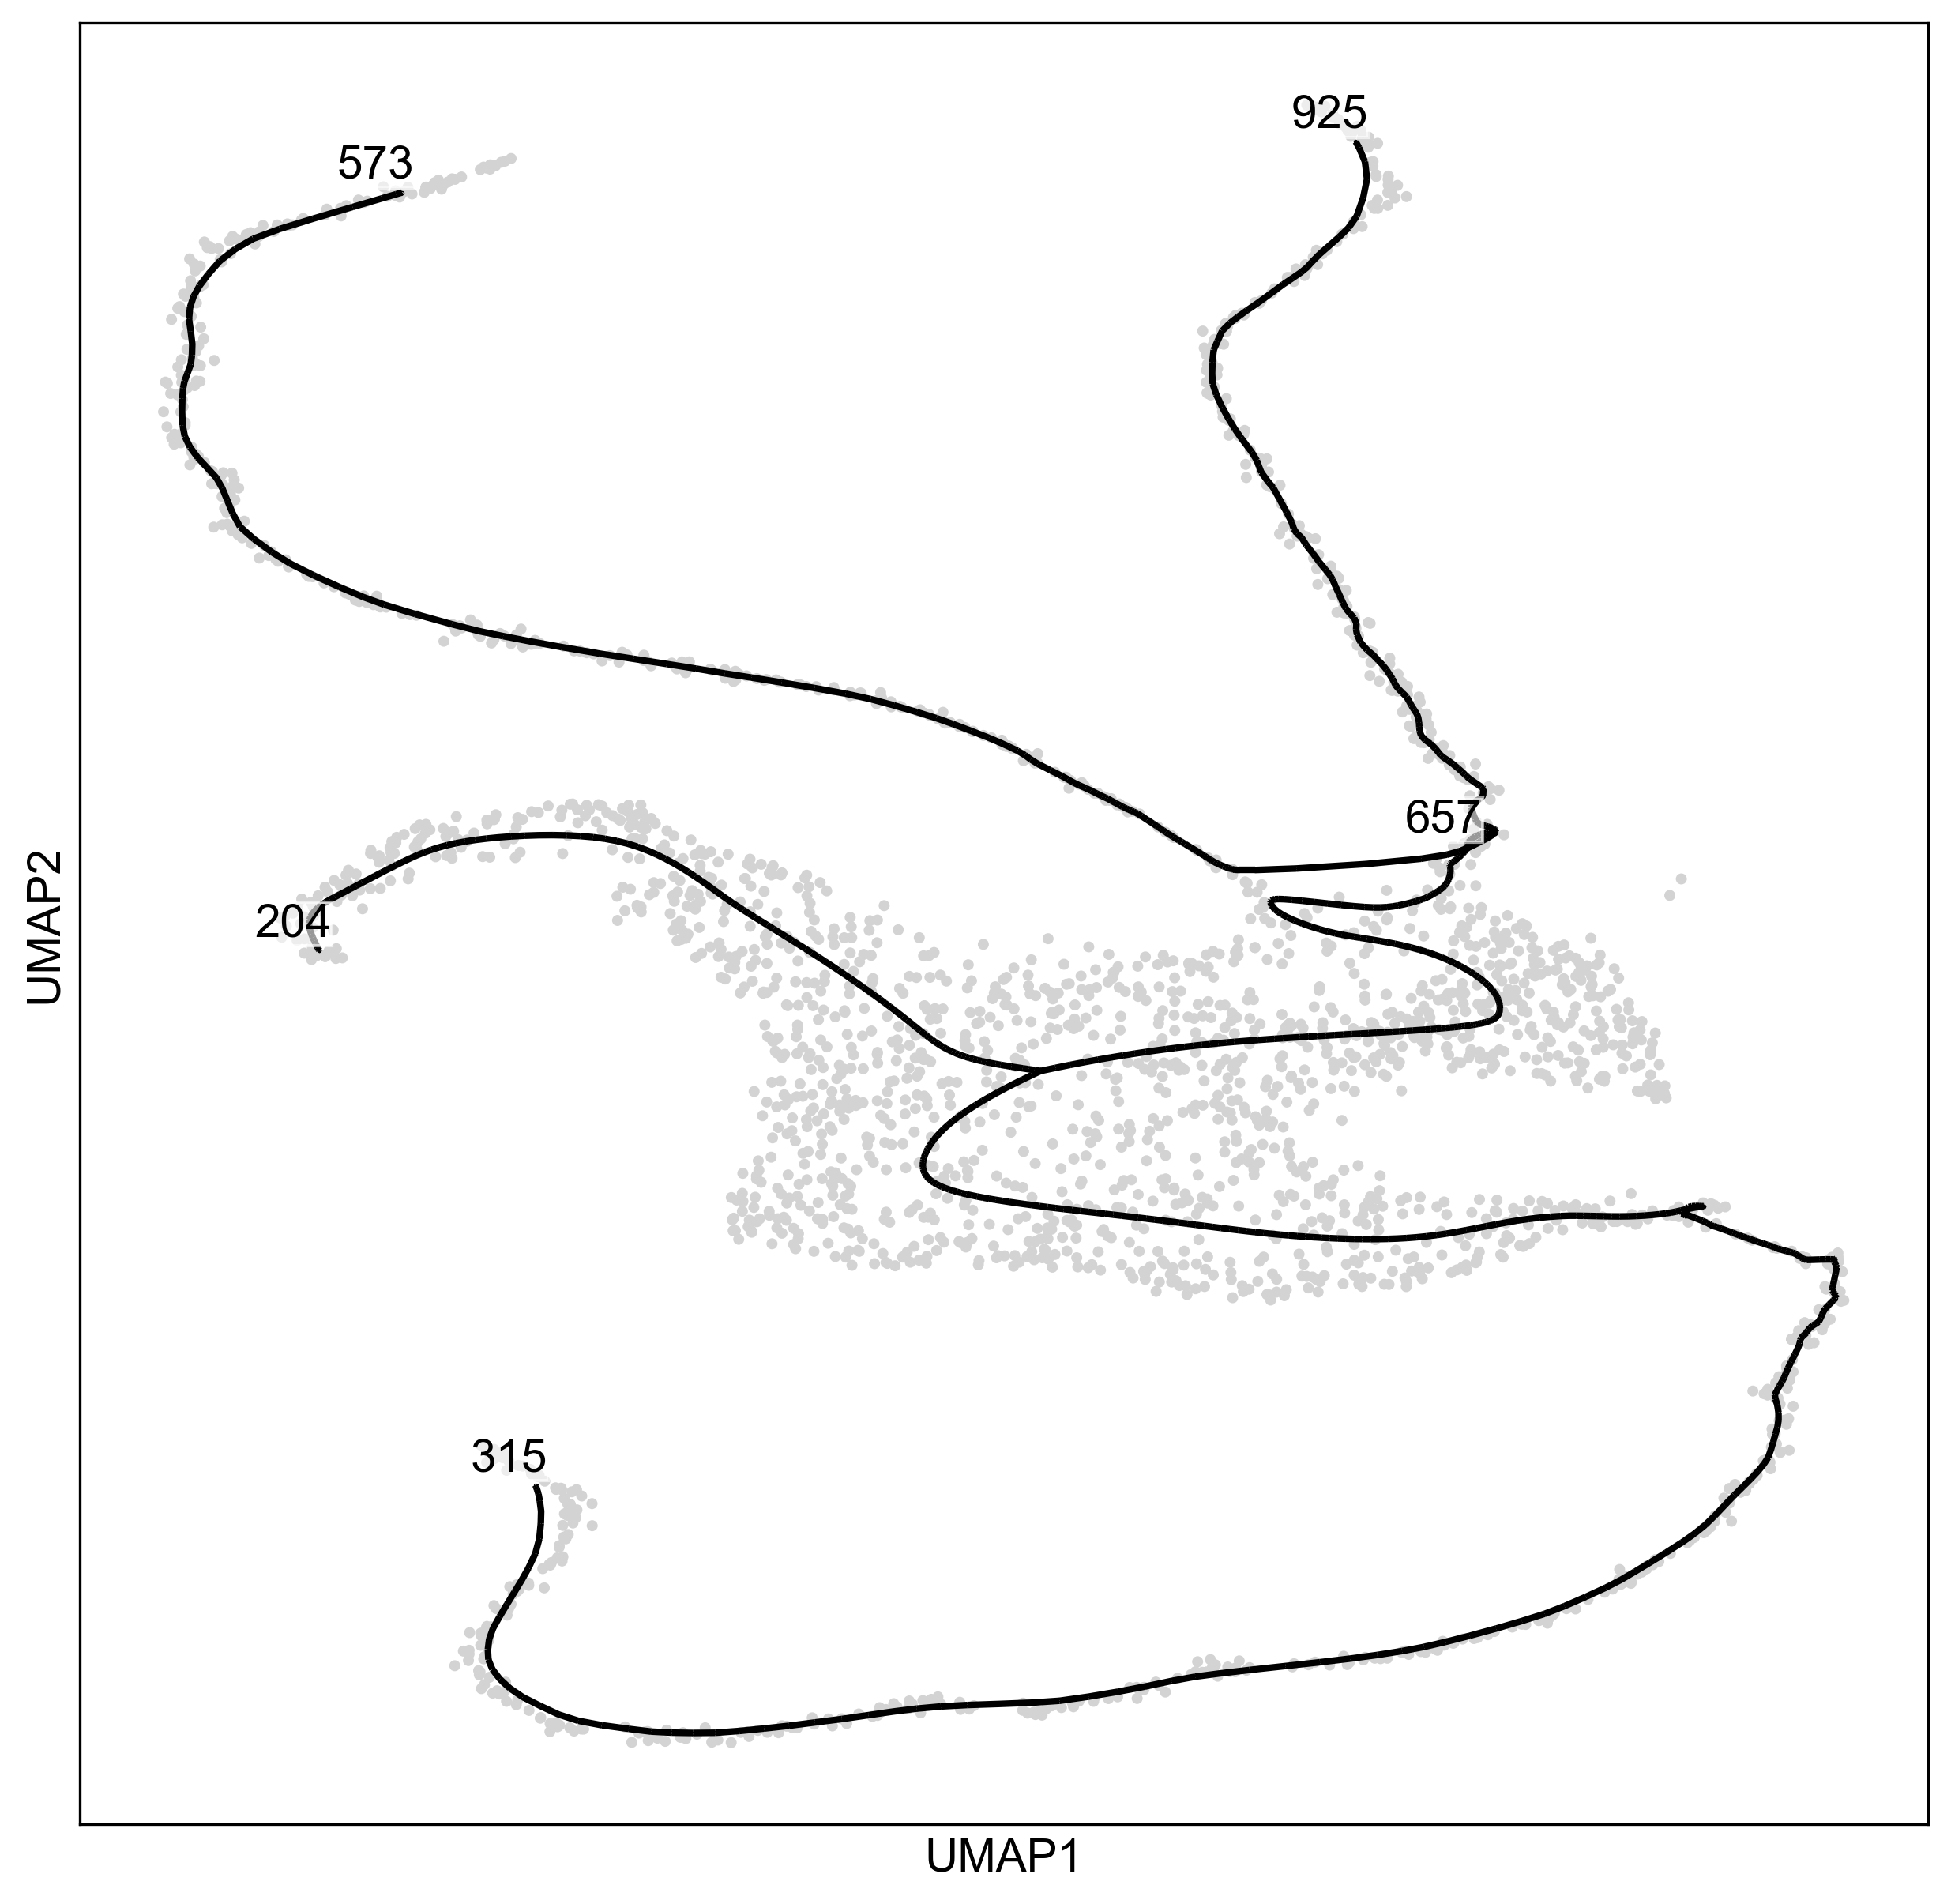

In [9]:
sc.set_figure_params(dpi=150,figsize=(10,10))
scf.pl.graph(adata,size_nodes=.1,forks=False)

In [10]:
import igraph
import pandas as pd
B = adata.uns["graph"]["B"]
tips = adata.uns["graph"]["tips"]
torem = []
g = igraph.Graph.Adjacency((B > 0).tolist(), mode="undirected")
tips = np.argwhere(np.array(g.degree()) == 1).flatten()
branches = np.argwhere(np.array(g.degree()) > 2).flatten()


dist = np.array(
    list(
        map(
            lambda t: np.min(
                list(map(len, g.get_all_shortest_paths(t, branches)))
            ),
            tips,
        )
    )
)

pd.Series(dist,index=tips)

204    133
315    364
573    152
657     12
925    118
dtype: int64

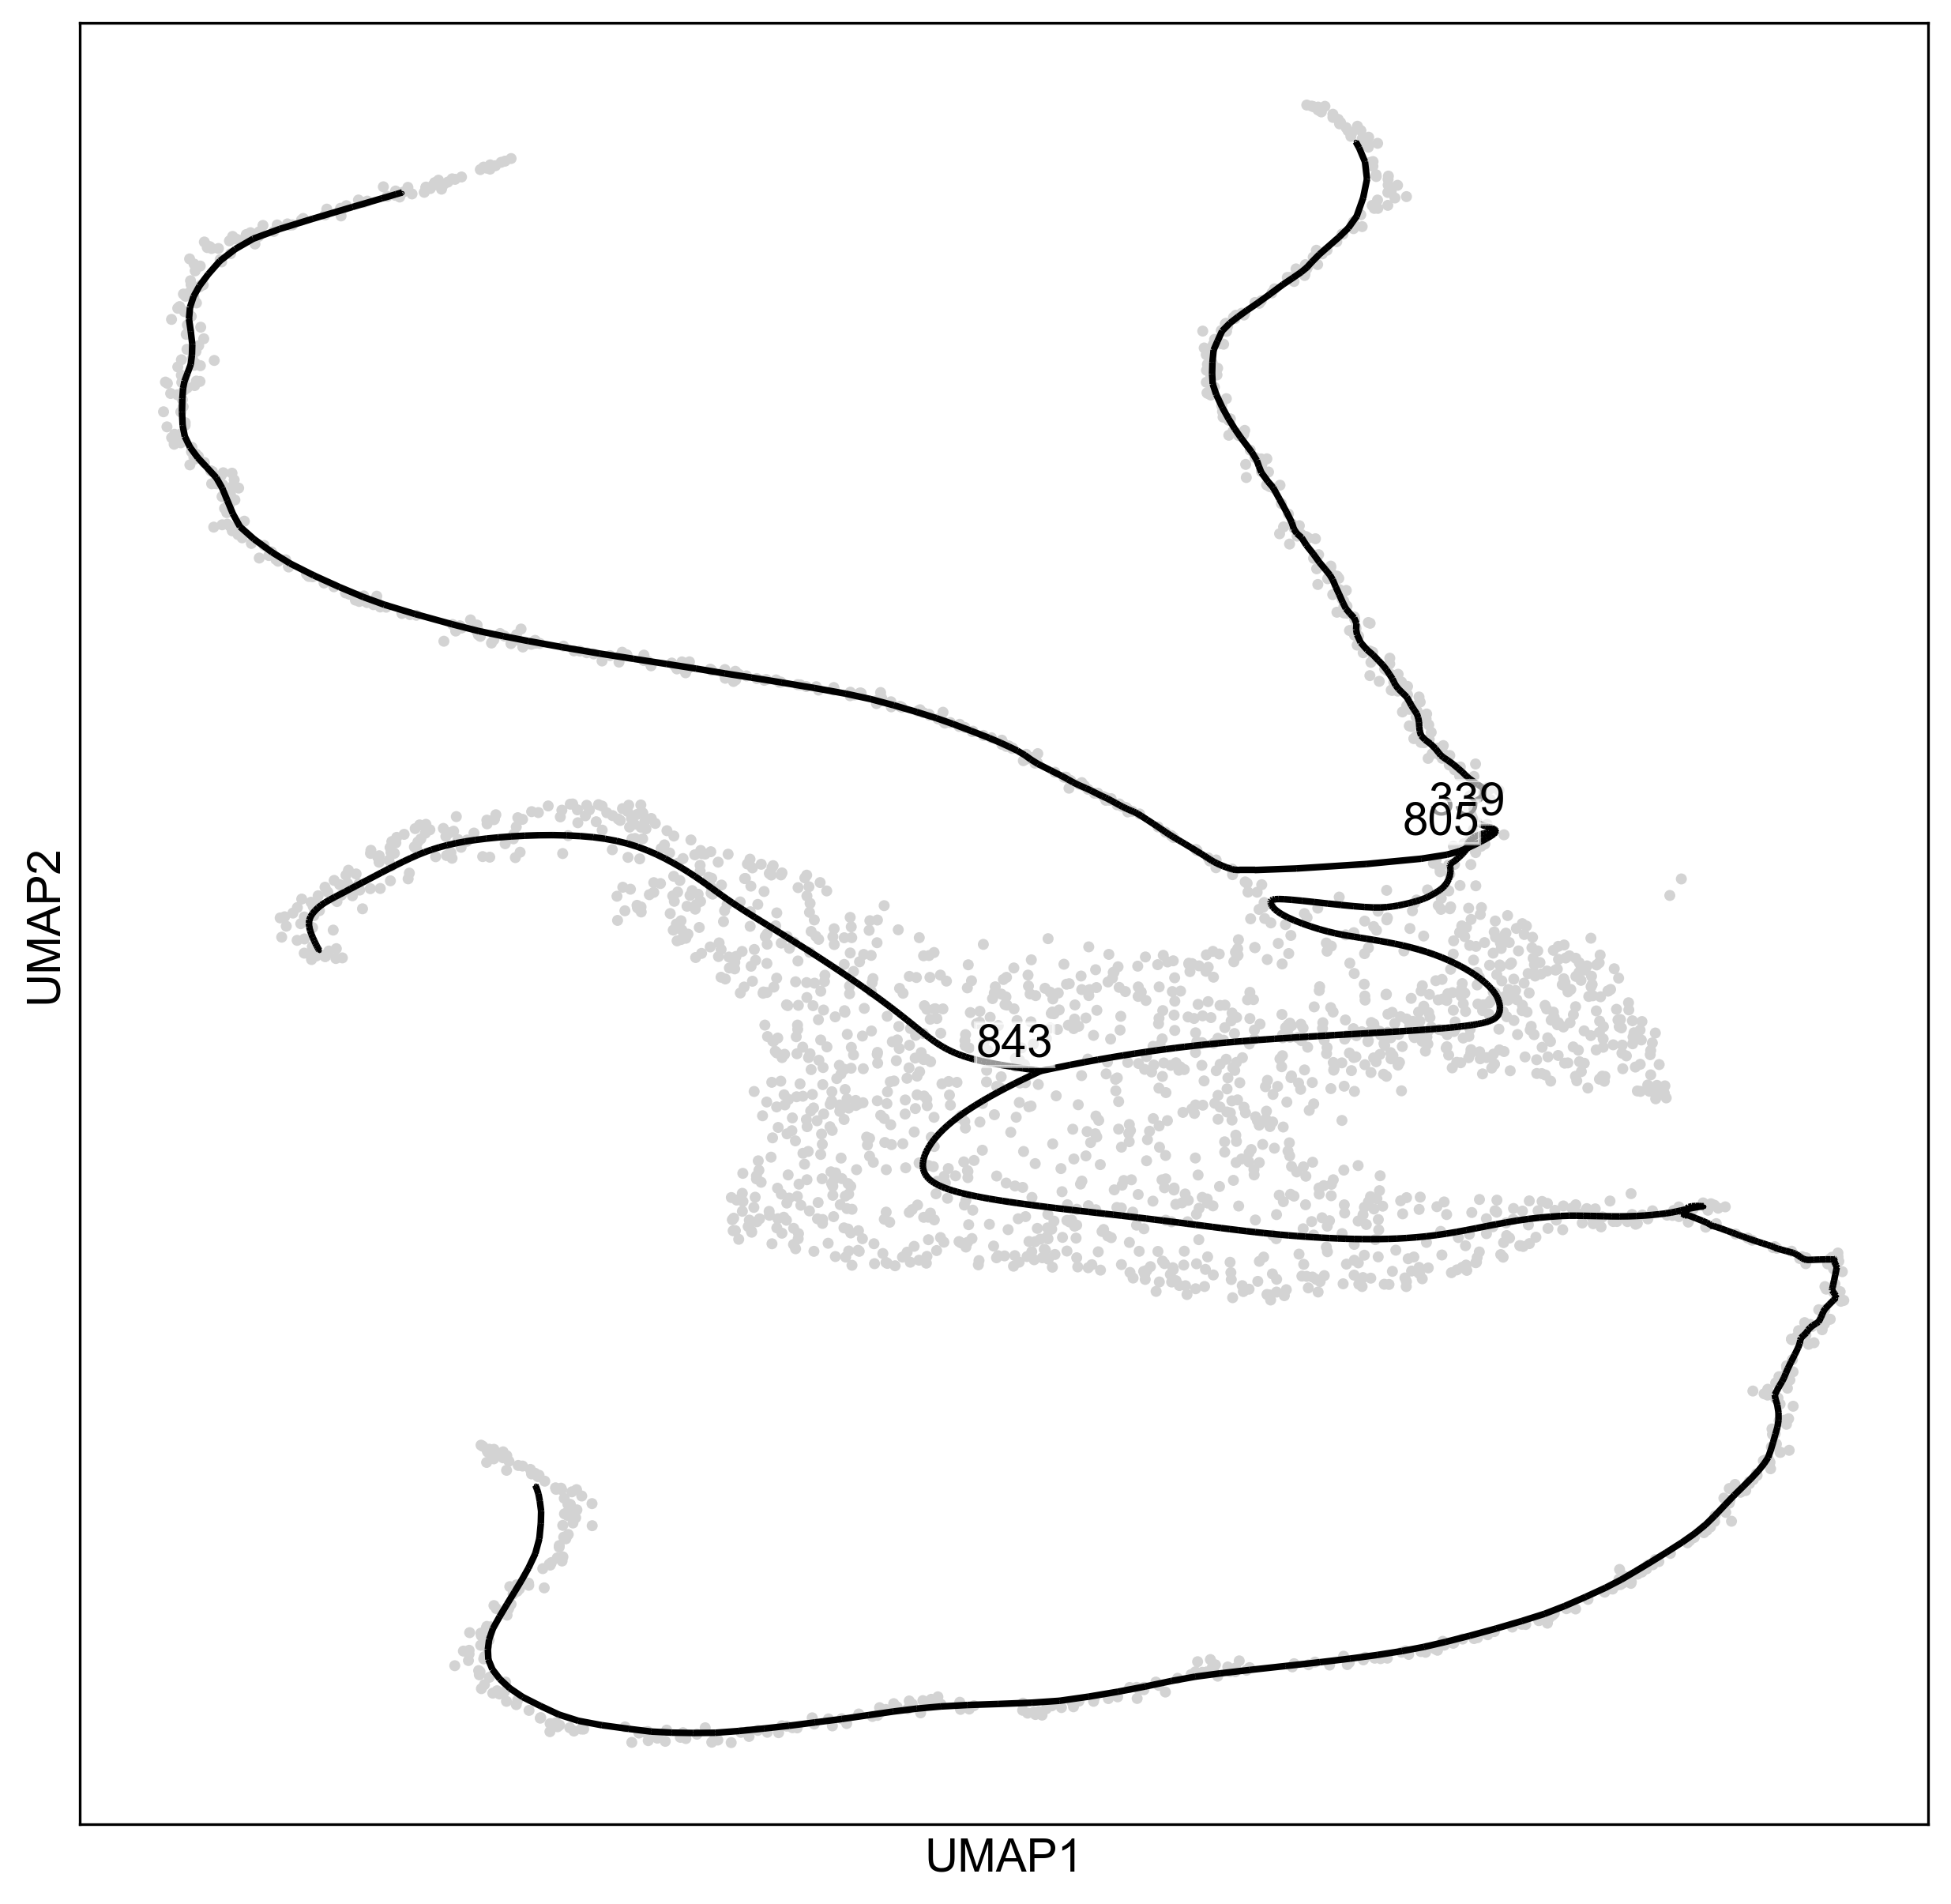

In [11]:
sc.set_figure_params(dpi=150,figsize=(10,10))
scf.pl.graph(adata,size_nodes=.1,tips=False)

In [12]:
#scf.tl.cleanup(adata,leaves=[47,293,300,237])
scf.tl.cleanup(adata,leaves=[657])

    graph cleaned --> removed 11 principal points


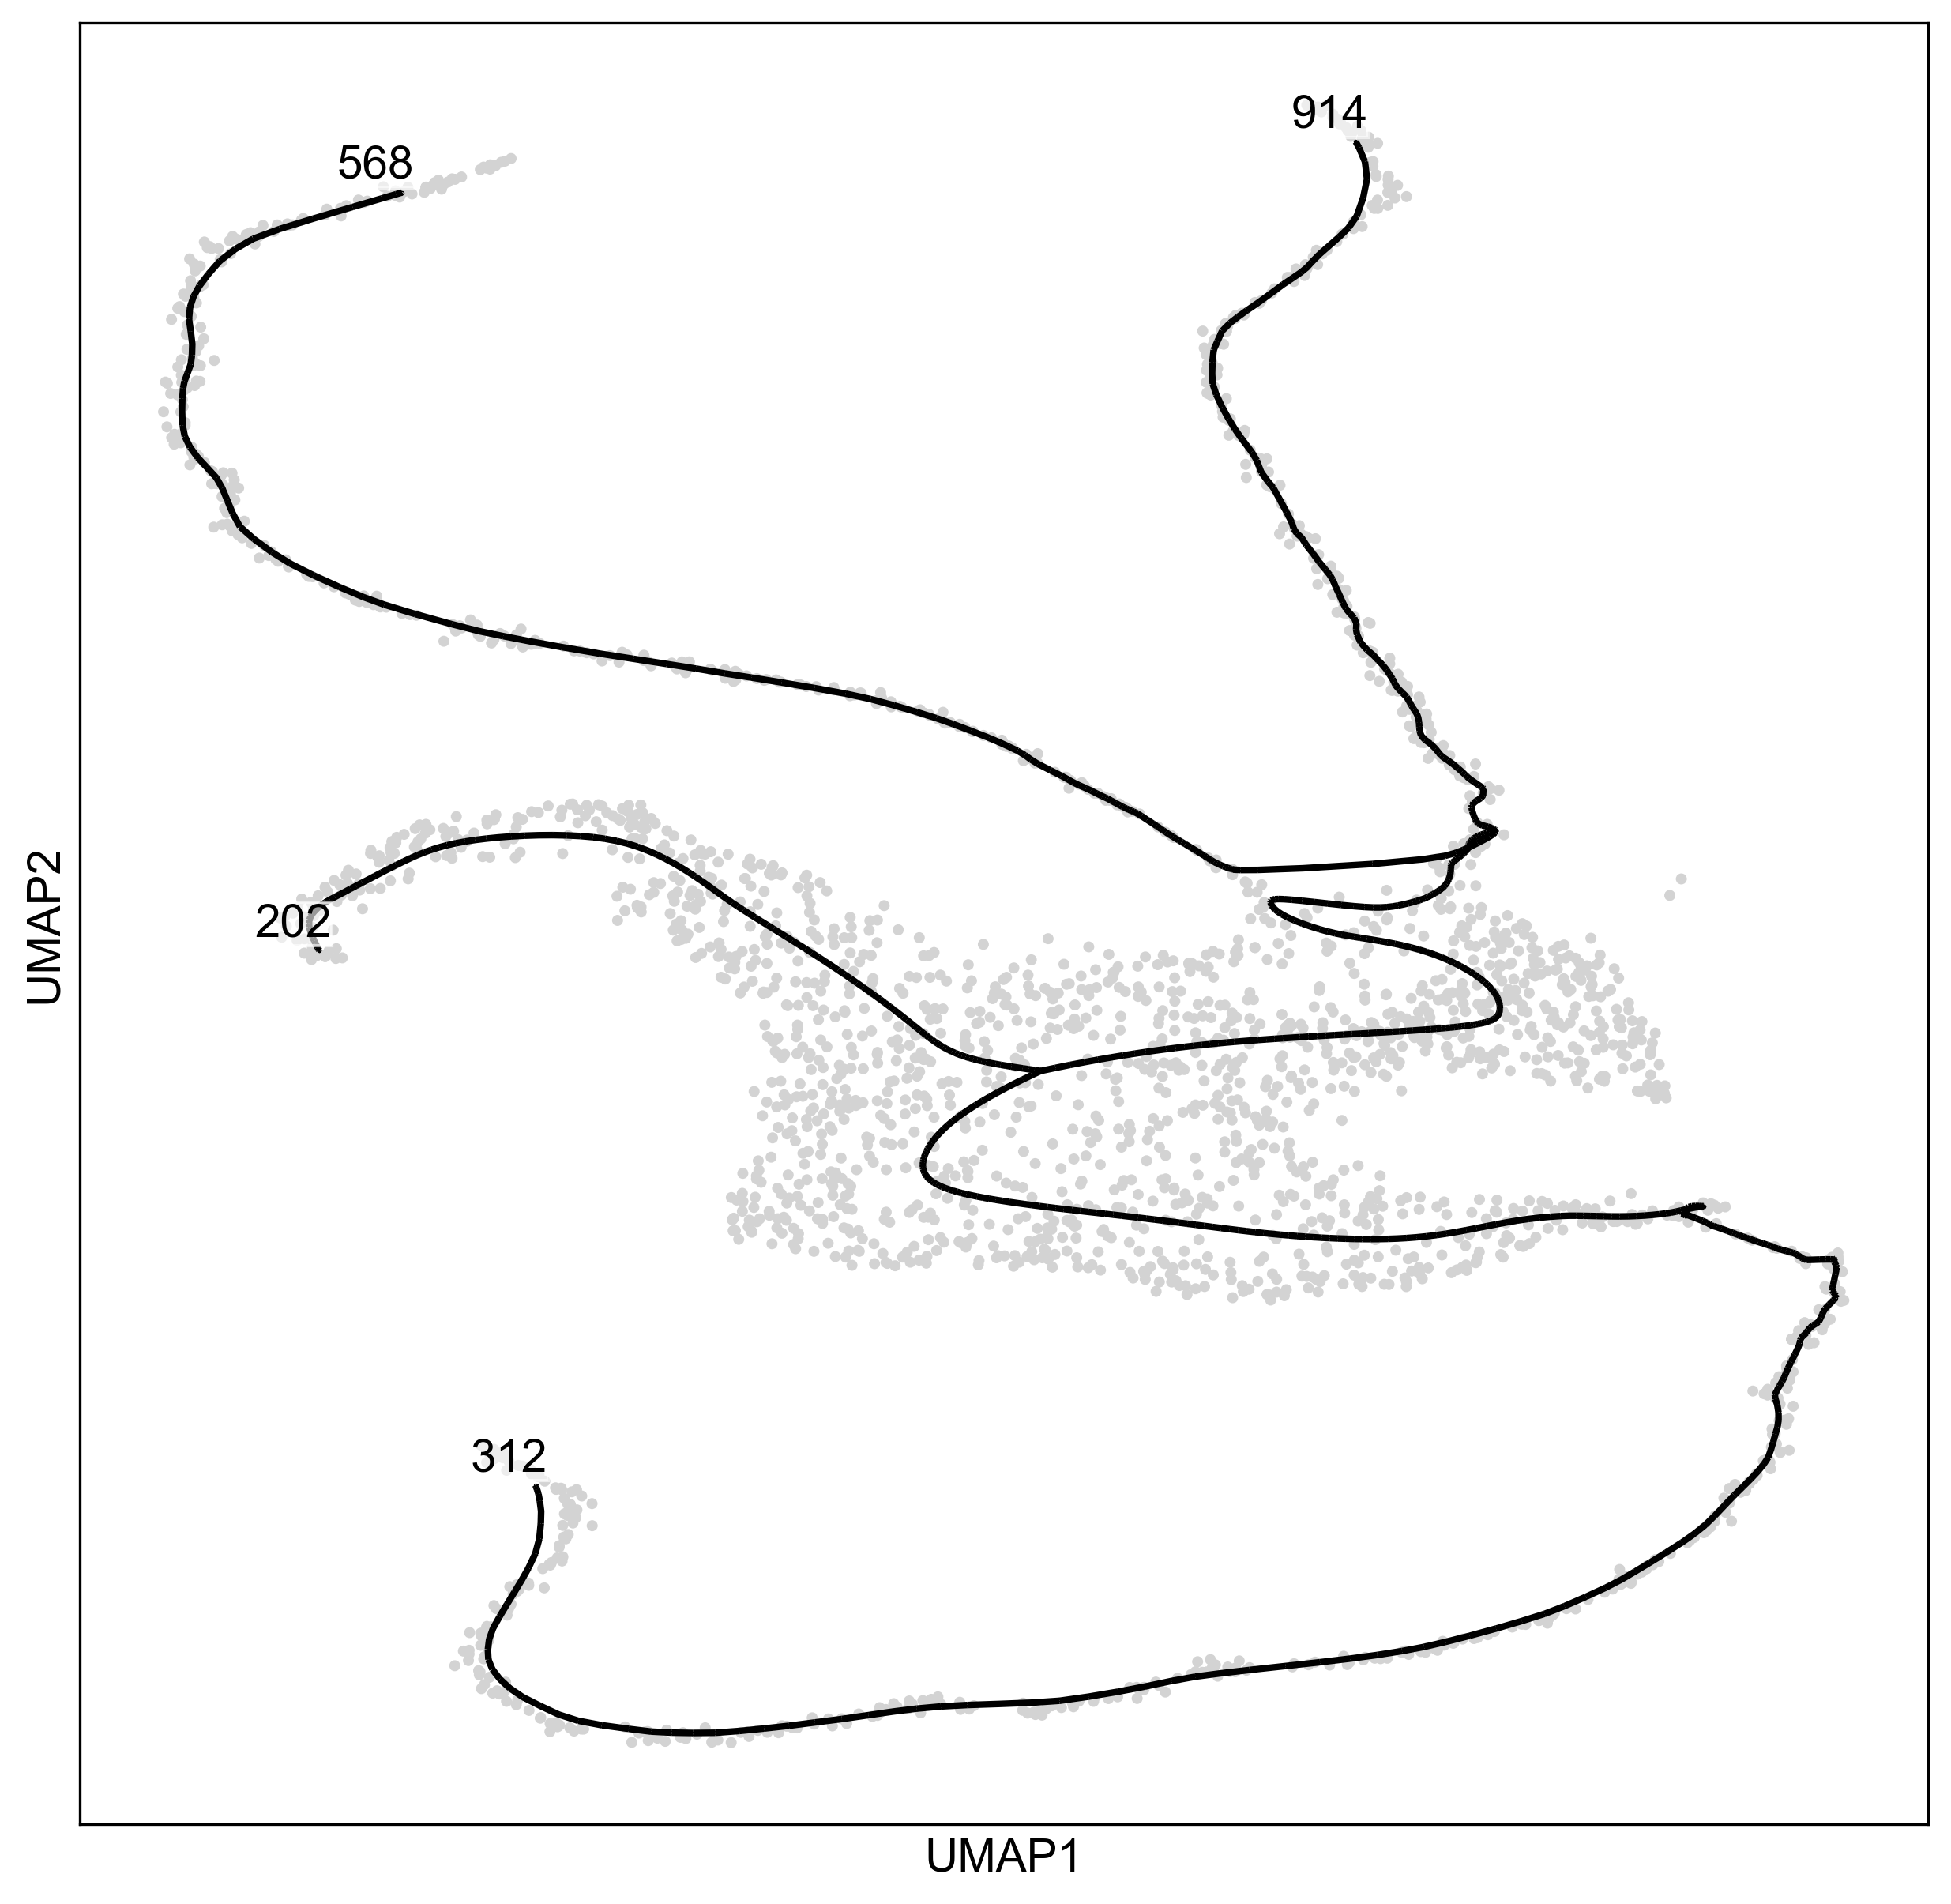

In [13]:
sc.set_figure_params(dpi=150,figsize=(10,10))
scf.pl.graph(adata,size_nodes=.1,forks=False)

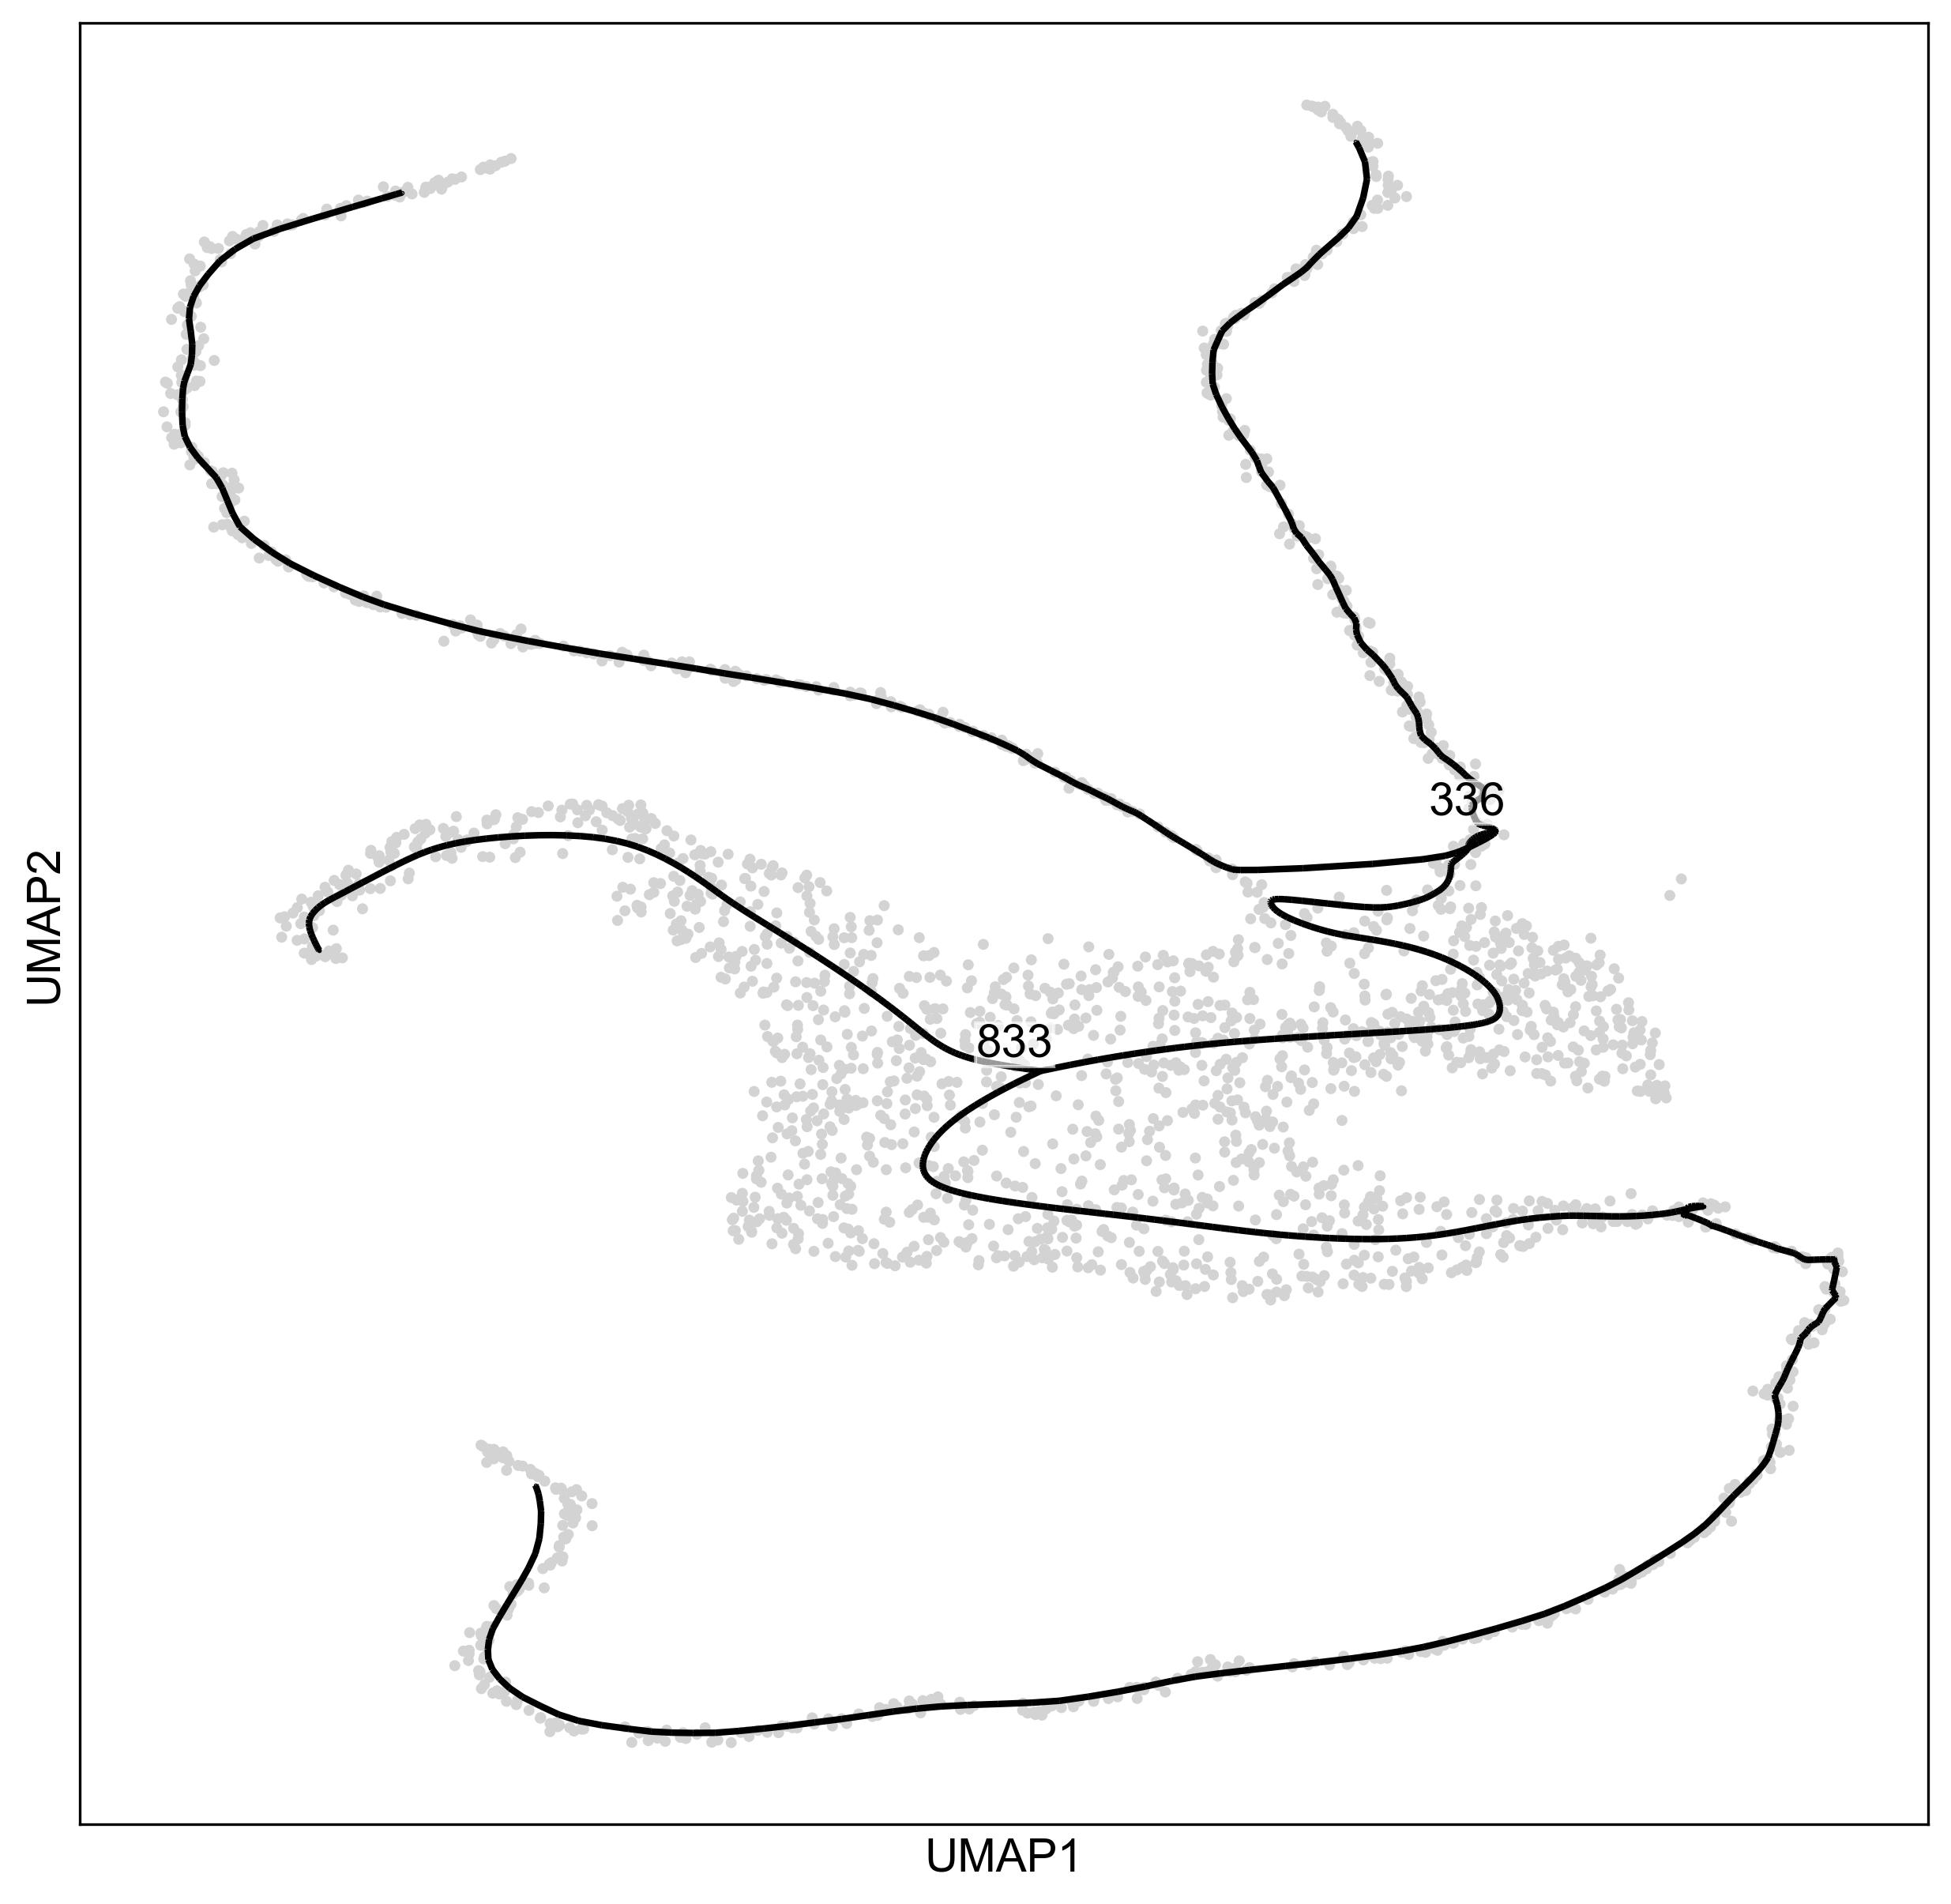

In [14]:
sc.set_figure_params(dpi=150,figsize=(10,10))
scf.pl.graph(adata,size_nodes=.1,tips=False)

In [15]:
#scf.tl.cleanup(adata,leaves=[475])

## Milestones graph

In [16]:
scf.tl.root(adata,833)
#scf.tl.roots(adata,[364,54,294],12) 

node 833 selected as a root --> added
    .uns['graph']['root'] selected root.
    .uns['graph']['pp_info'] for each PP, its distance vs root and segment assignment.
    .uns['graph']['pp_seg'] segments network information.


In [17]:
scf.tl.pseudotime(adata)

projecting cells onto the principal graph
    finished (0:00:03) --> added
    .obs['edge'] assigned edge.
    .obs['t'] pseudotime value.
    .obs['seg'] segment of the tree assigned.
    .obs['milestones'] milestone assigned.
    .uns['pseudotime_list'] list of cell projection from all mappings.


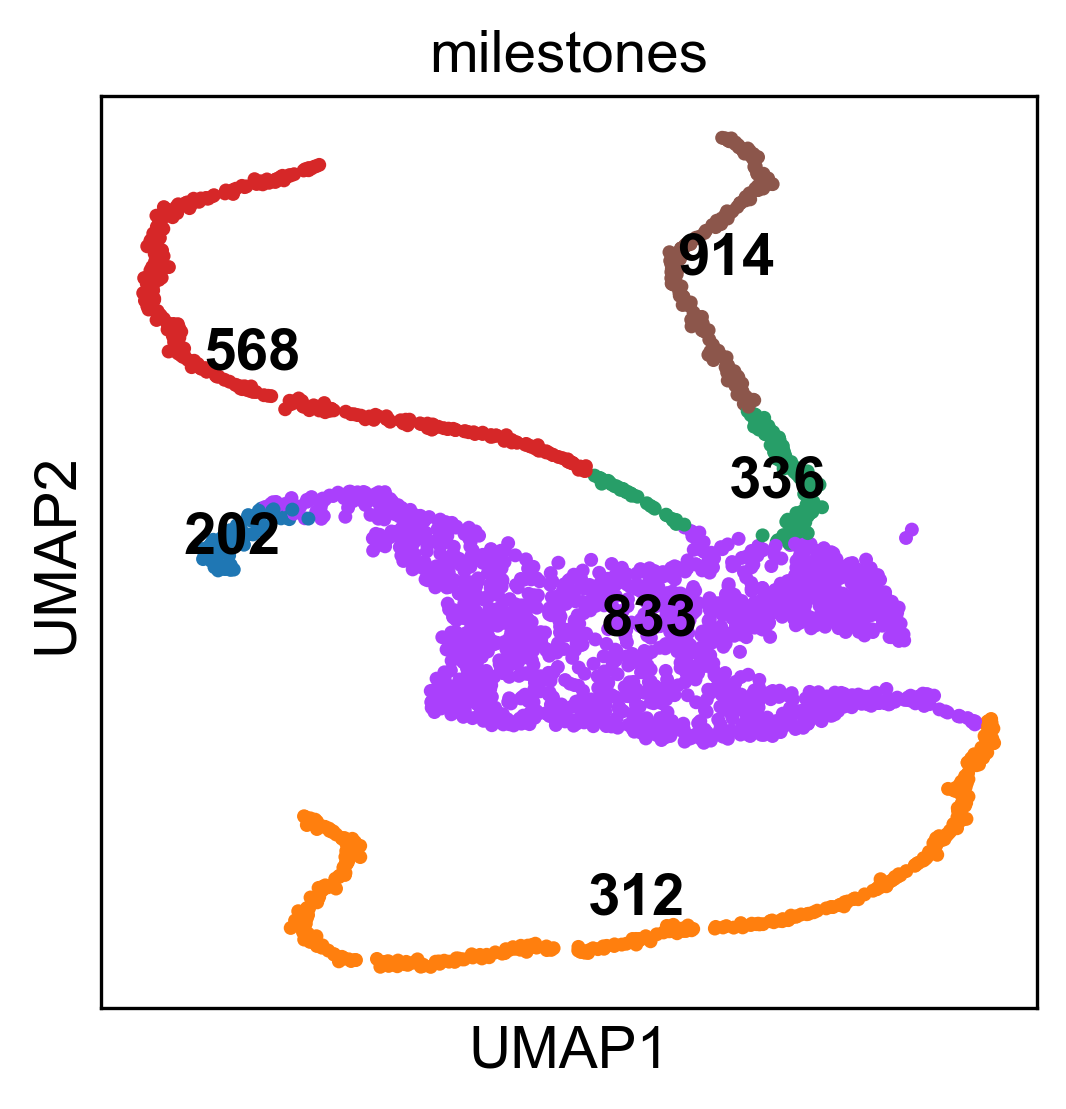

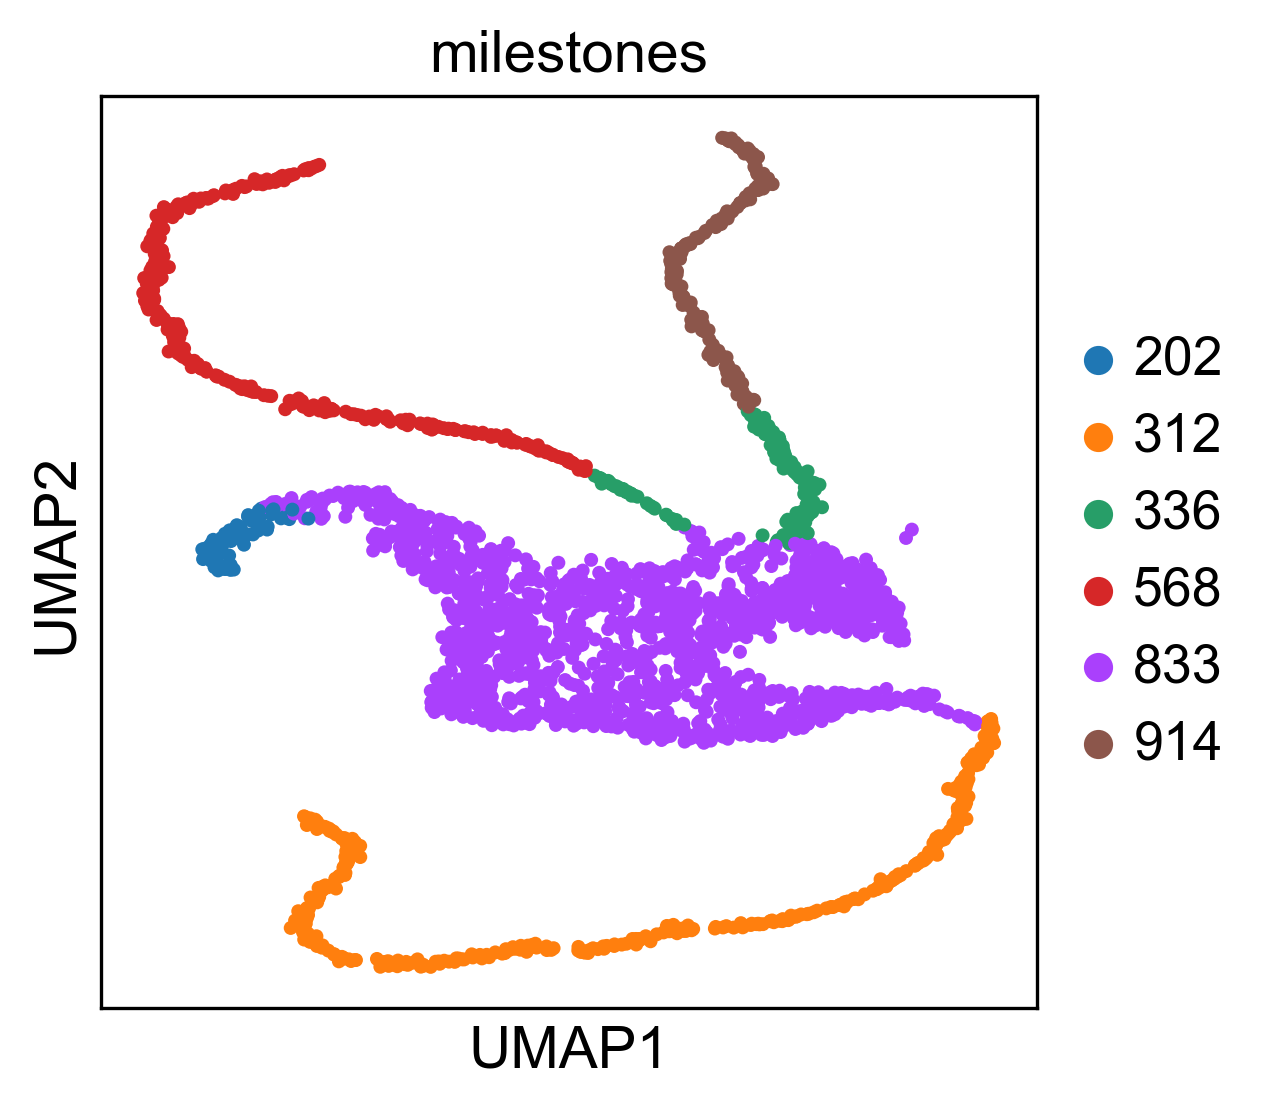

In [18]:
sc.set_figure_params(dpi=150)
sc.pl.umap(adata,color="milestones",legend_loc="on data")
sc.pl.umap(adata,color="milestones")

In [19]:
assign={"312":"MYCN+ NB",
        "202":"ALK+ NB",
        "336":"Progenitor > ATRX+",
        "568":"ATRX+ NB1",
        "833":"Progenitor",
        "914":"ATRX+ NB2"}

In [20]:
scf.tl.rename_milestones(adata,[assign[m] for m in adata.obs.milestones.cat.categories])

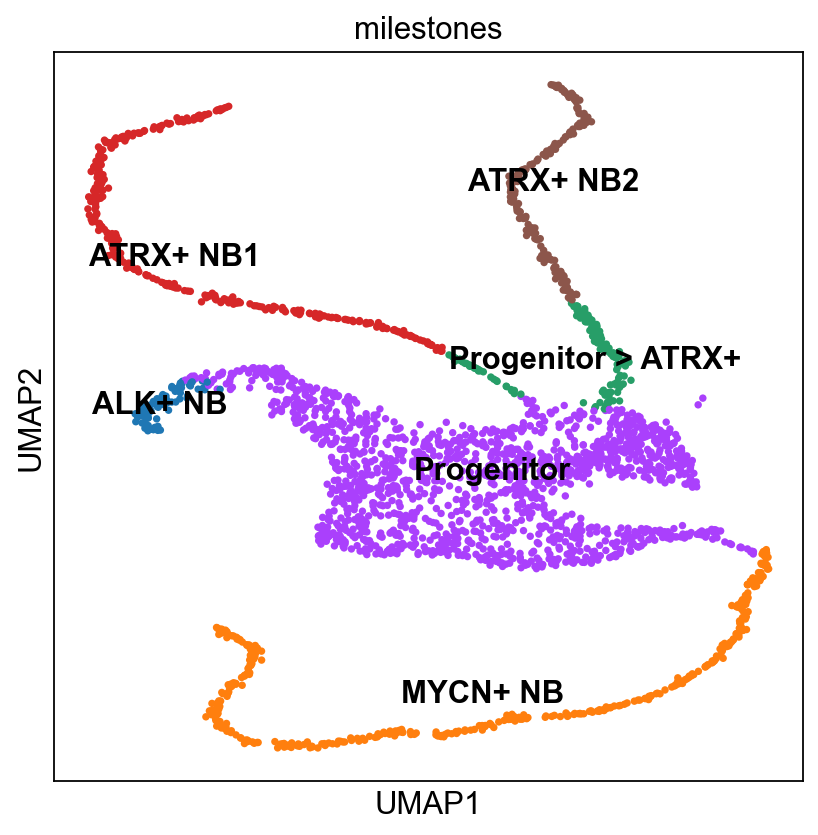

In [21]:
sc.set_figure_params(figsize=(6,6))
sc.pl.umap(adata,color="milestones",legend_loc="on data")

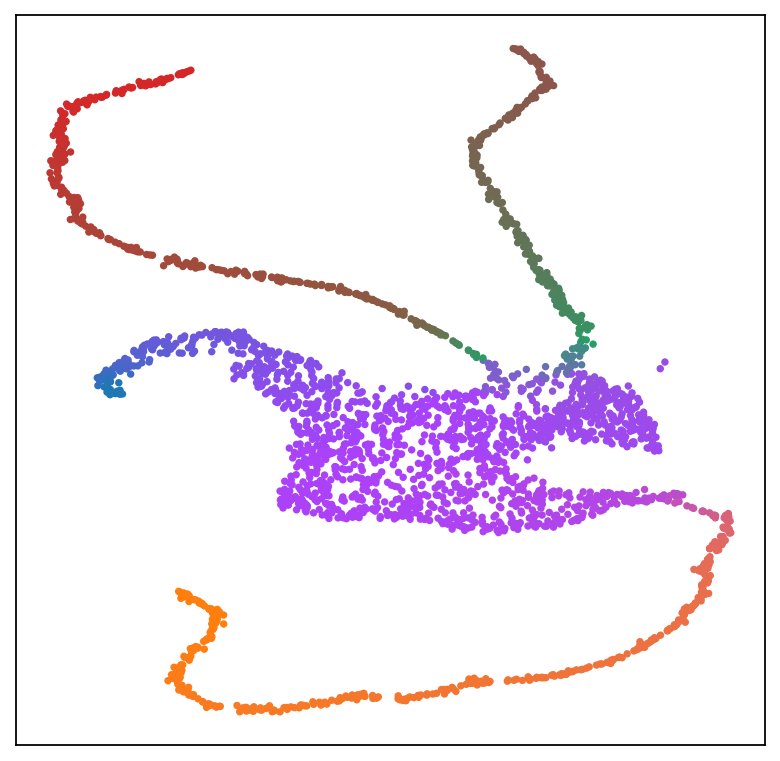

In [22]:
scf.pl.milestones(adata)

In [23]:
from typing import Literal
import igraph

def milestones_graph(
    adata,
    color=None,
    cmap=None,
    roots=None,
    layout: Literal["dendro", "reingold_tilford"] = "dendro",
    figsize=(500, 500),
    ):
    """\
    Display the milestone graph in PAGA style.

    Parameters
    ----------
    adata
        Annotated data matrix.
    color
        color the milestones with variable from adata.obs.
    cmap
        colormap to use for the node coloring.
    roots
        select milestones to position on top fo the plot.
    dendro
        generate layout following dendrogram representation.
    figsize
        figure size in pixels
    
    Returns
    -------
    igraph.plot
    
    """
    
    graph = adata.uns["graph"]
    
    dct = graph["milestones"]
    keys = np.array(list(dct.keys()))
    vals = np.array(list(dct.values()))
    
    edges = graph["pp_seg"][["from", "to"]].astype(str).apply(tuple, axis=1).values
    img = igraph.Graph(directed=True)
    img.add_vertices(vals.astype(str))
    img.add_edges(edges)
    
    img.vs["label"] = keys
    
    dct = dict(zip(img.vs["name"], img.vs["label"]))
    if roots is None:
        if "root2" not in adata.uns["graph"]:
            roots = [dct[str(adata.uns["graph"]["root"])]]
        else:
            roots = [
                dct[str(adata.uns["graph"]["root"])],
                dct[str(adata.uns["graph"]["root2"])],
            ]
            if layout == "dendro":
                logg.warn("two roots detected, reverting to reingold_tilford layout")
                layout = "reingold_tilford"
    
    if color is None:
        if "milestones_colors" not in adata.uns:
            from . import palette_tools
    
            palette_tools._set_default_colors_for_categorical_obs(adata, "milestones")
        img.vs["color"] = [
            np.array(adata.uns["milestones_colors"])[
                adata.obs.milestones.cat.categories == dct[m]
            ][0]
            for m in img.vs["name"]
        ]
    else:
        if cmap is None:
            cmap = "viridis"
        g = adata.obs.groupby("milestones")
        val_milestones = g.apply(lambda x: np.mean(x[color]))
        norm = matplotlib.colors.Normalize(
            vmin=min(val_milestones), vmax=max(val_milestones), clip=True
        )
        mapper = cm.ScalarMappable(norm=norm, cmap=eval("cm." + cmap))
        c_mil = list(
            map(lambda m: mcolors.to_hex(mapper.to_rgba(m)), val_milestones.values)
        )
        img.vs["color"] = c_mil
    
    if layout == "dendro":
        pos = hierarchy_pos(img.to_networkx(), vert_gap=0.1)
        pos = pd.DataFrame([pos[s] for s in np.sort(np.array(list(pos.keys())))])
        pos.iloc[:, 1] = -pos.iloc[:, 1]
        layout = list(pos.to_records(index=False))
    else:
        layout = img.layout_reingold_tilford(
            root=list(
                map(
                    lambda root: np.argwhere(np.array(img.vs["label"]) == root)[0][0],
                    roots,
                )
            )
        )
    
    return igraph.plot(img, bbox=figsize, layout=layout, margin=50)

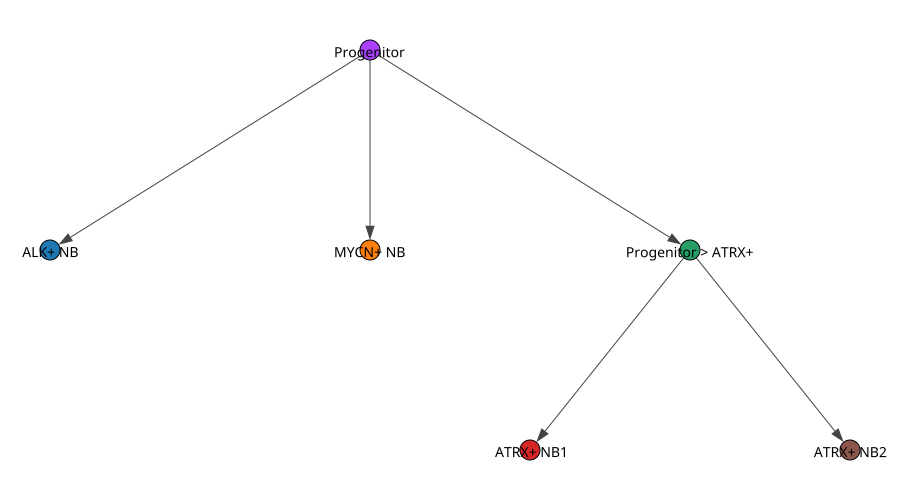

In [24]:
milestones_graph(adata,
              roots=["Progenitor"],
              layout="reingold_manifold",
              figsize=(900,500)
              )

In [25]:
#scf.tl.subset_tree(adata,root_milestone="Progenitor",milestones=["ALK+ NB","ATRX+ NB1","ATRX+ NB2","MYCN+ NB1","MYCN+ NB2","MYCN+ NB3"])

# Trajectory

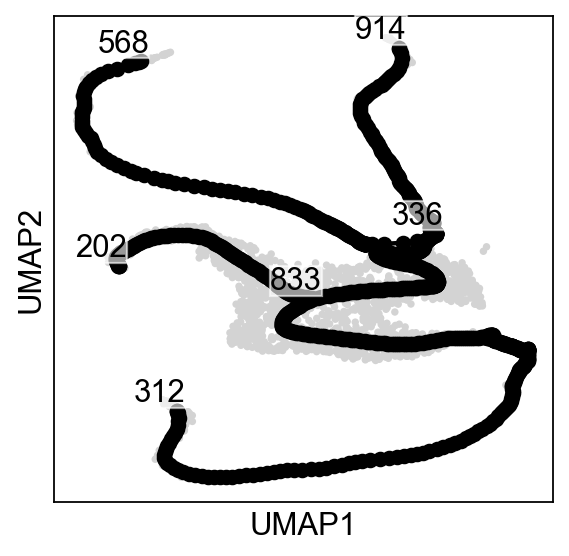

In [26]:
sc.set_figure_params()
scf.pl.graph(adata)

## Dendrogram

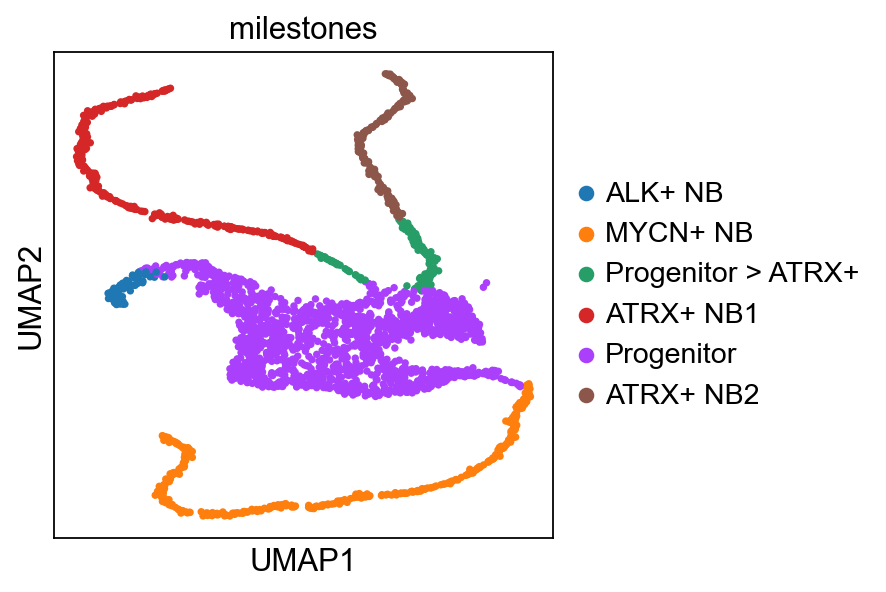

In [27]:
sc.pl.umap(adata,color="milestones")

In [30]:
#scf.tl.subset_tree(adata,root_milestone="Progenitor",milestones=["ALK+ NB","MYCN+ NB1","ATRX+ NB1","ATRX+ NB2"])

In [31]:
#sc.pl.umap(adata,color="old_milestones")

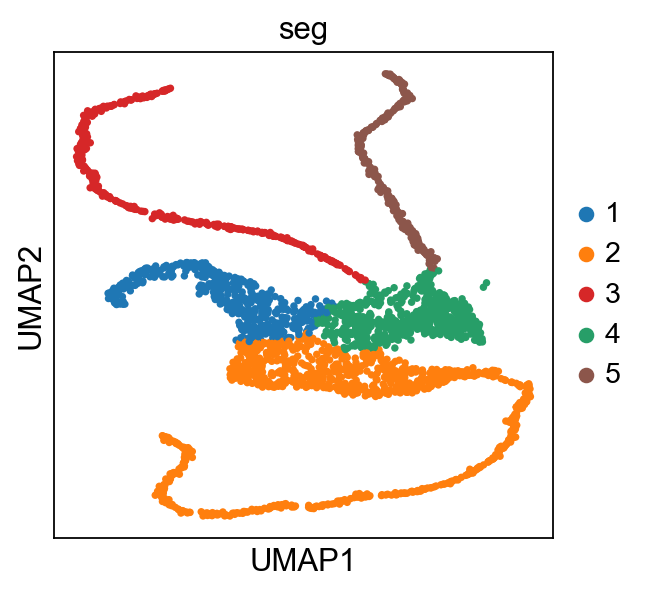

In [32]:
sc.pl.umap(adata,color="seg")

Generating dendrogram of tree
    finished (0:00:00) --> added 
    .obsm['X_dendro'], new embedding generated.
    .uns['dendro_segments'] tree segments used for plotting.


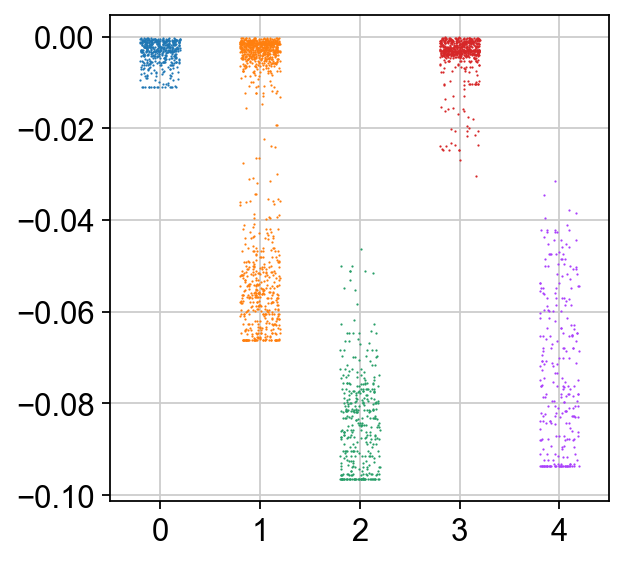

In [33]:
scf.tl.dendrogram(adata)

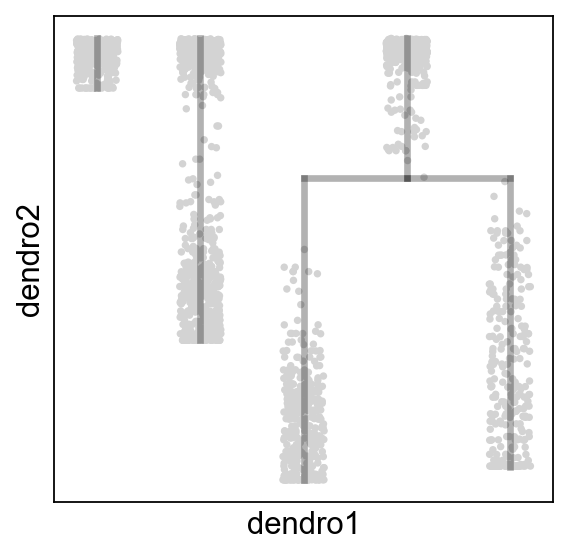

In [34]:
scf.pl.dendrogram(adata)

In [36]:
#SUPER LONG
scf.tl.test_association(adata,n_jobs=20,A_cut=0.015)

test features for association with the trajectory
    single mapping :   1%|▏         | 4509/331361 [00:59<1:12:19, 75.32it/s]

/home/matei/anaconda3/envs/neuroblastoma/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


    single mapping :   7%|▋         | 24521/331361 [10:44<2:14:26, 38.04it/s]

IOStream.flush timed out


    single mapping : 100%|██████████| 331361/331361 [2:28:58<00:00, 37.07it/s]  
    found 11773 significant features (2:28:59) --> added
    .var['p_val'] values from statistical test.
    .var['fdr'] corrected values from multiple testing.
    .var['st'] proportion of mapping in which feature is significant.
    .var['A'] amplitue of change of tested feature.
    .var['signi'] feature is significantly changing along pseudotime.
    .uns['stat_assoc_list'] list of fitted features on the graph for all mappings.


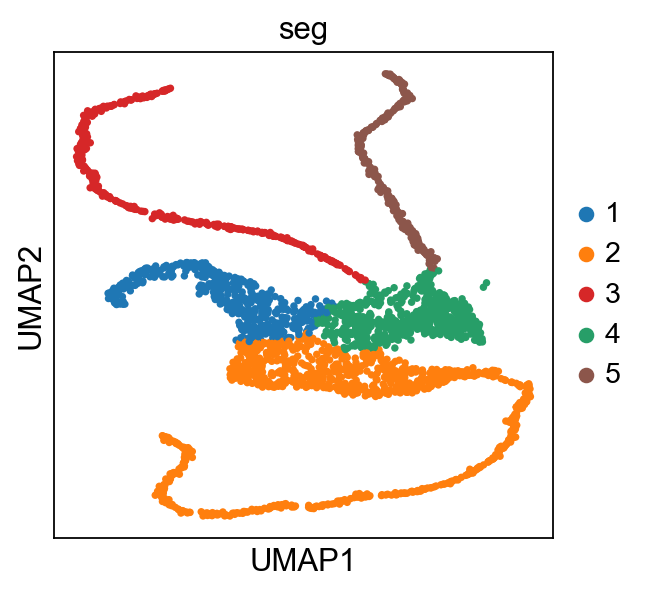

In [38]:
sc.pl.umap(adata,color="seg")

In [40]:
scf.tl.pseudotime(adata)

projecting cells onto the principal graph
    finished (0:00:04) --> added
    .obs['edge'] assigned edge.
    .obs['t'] pseudotime value.
    .obs['seg'] segment of the tree assigned.
    .obs['milestones'] milestone assigned.
    .uns['pseudotime_list'] list of cell projection from all mappings.


In [44]:
scf.tl.fit(adata,n_jobs=20,gamma=5)

fit features associated with the trajectory
    single mapping :   0%|          | 0/11773 [00:00<?, ?it/s]

/home/matei/anaconda3/envs/neuroblastoma/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


    single mapping :  41%|████      | 4848/11773 [01:54<02:43, 42.27it/s]

/home/matei/anaconda3/envs/neuroblastoma/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


    single mapping :  41%|████▏     | 4864/11773 [01:57<02:47, 41.28it/s]

...

    single mapping :  90%|████████▉ | 10589/11773 [06:08<00:41, 28.76it/s]

/home/matei/anaconda3/envs/neuroblastoma/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


    single mapping :  94%|█████████▍| 11067/11773 [06:21<00:24, 28.99it/s]

/home/matei/anaconda3/envs/neuroblastoma/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


    single mapping : 100%|██████████| 11773/11773 [06:39<00:00, 29.49it/s]
    finished (adata subsetted to keep only fitted features!) (0:06:50) --> added
    .layers['fitted'], fitted features on the trajectory for all mappings.
    .raw, unfiltered data.


In [72]:
adata.var.to_csv("/home/matei/data/stat_assoc_genes.csv")

Generating dendrogram of tree
    finished (0:00:00) --> added 
    .obsm['X_dendro'], new embedding generated.
    .uns['dendro_segments'] tree segments used for plotting.


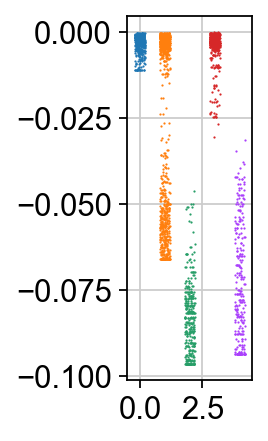

In [46]:
scf.tl.dendrogram(adata)

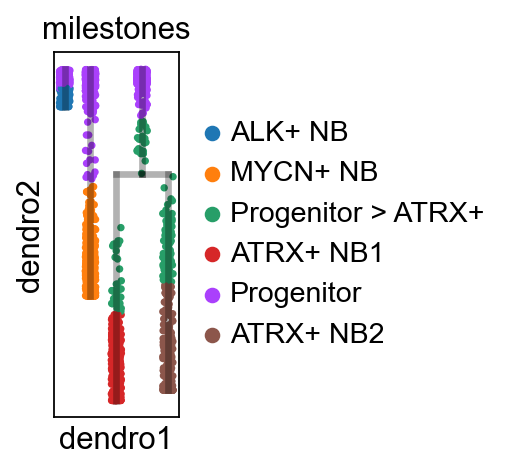

In [47]:
scf.pl.dendrogram(adata,color="milestones")

## Plotting HVGs

### HVGs list

In [67]:
adata.var[adata.var["gene"]=="ALK"]

,gene,transcript,transcript_type,tag,level,transcript_support_level,annot_remark,ERCC,mt,ribo,...,res,lp,lpa,qv,highly_variable,p_val,A,fdr,st,signi
ENST00000642122.1,ALK,ALK-207,protein_coding,CCDS,2.0,Unknown,Unknown,False,False,False,...,0.019040,-0.896863,-0.024746,1.004943,False,1.246252e-147,0.265543,4.129593e-142,1,True
ENST00000389048.8,ALK,ALK-201,protein_coding,CCDS,2.0,1.0,['MANE_select'],False,False,False,...,0.263934,-5.419167,-2.241967,1.061161,False,1.576816e-50,0.117921,5.224953e-45,1,True
ENST00000638605.1,ALK,ALK-206,protein_coding_CDS_not_defined,Unknown,2.0,1.0,['Transcript variant based on PPFIBP1-ALK fusi...,False,False,False,...,-0.086074,-0.206794,0.000000,0.979171,False,1.162396e-46,0.182309,3.851726e-41,1,True


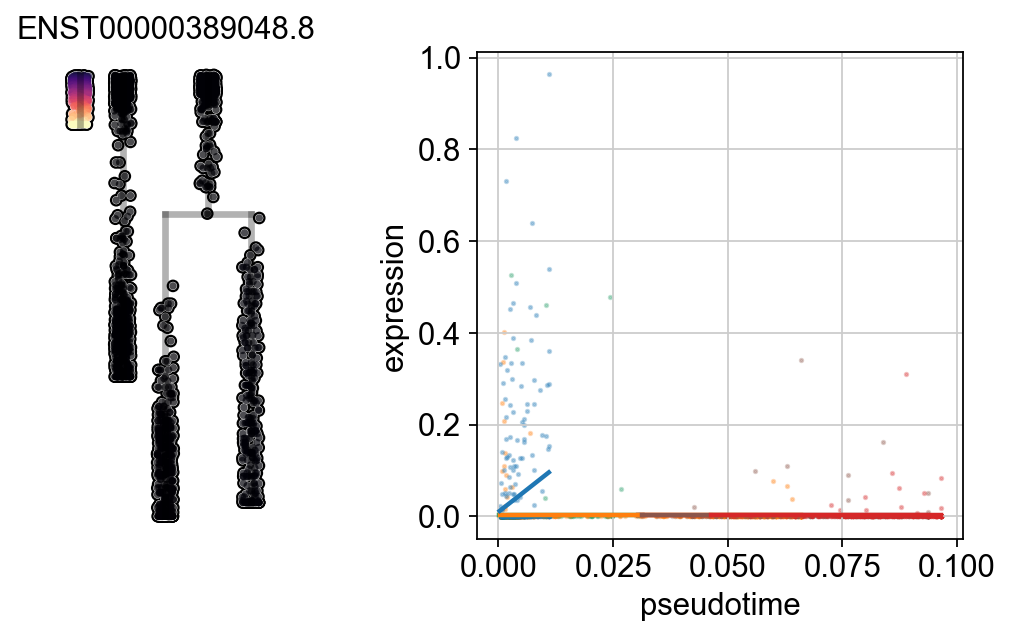

In [70]:
sc.set_figure_params(figsize=(1,3))

gene = adata.var[adata.var["transcript"]=="ALK-201"].index[0]

scf.pl.single_trend(adata, feature = gene, basis="dendro",cmap_cells="magma",
                    frameon=False,add_outline=True)

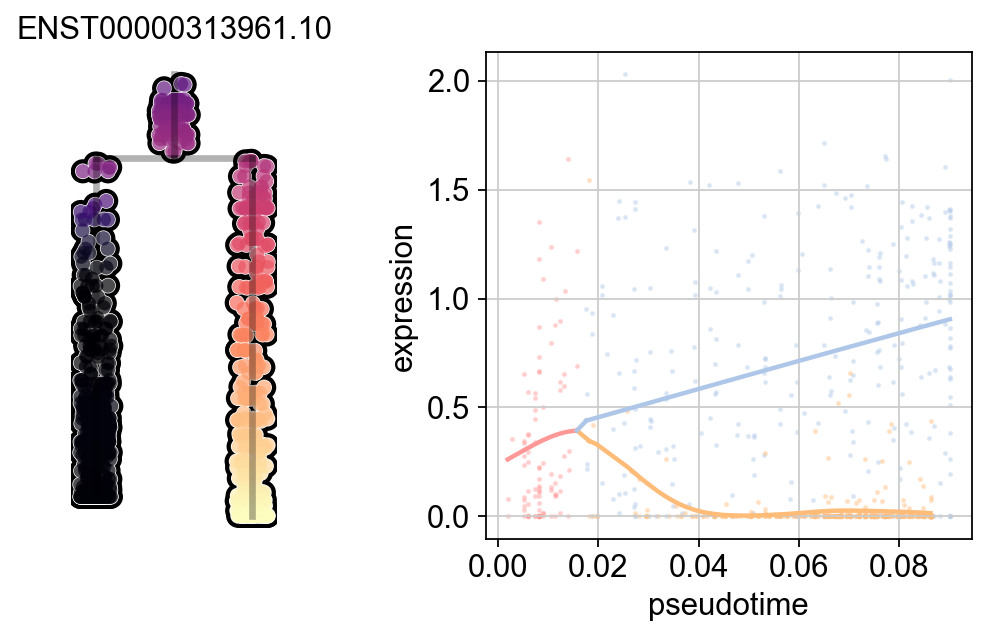

In [131]:
sc.set_figure_params(figsize=(1,3))

gene = adata.var[adata.var["gene"]=="RGS5"].index[0]

scf.pl.single_trend(adata, feature = gene, basis="dendro",cmap_cells="magma",
                    frameon=False,add_outline=True)

In [110]:
sc.set_figure_params(figsize=(1,3))

gene = adata.var[adata.var["gene"]=="KIF1A"].index[0]

scf.pl.single_trend(adata, feature = gene, basis="dendro",cmap_cells="magma",
                    frameon=False,add_outline=True)

[]

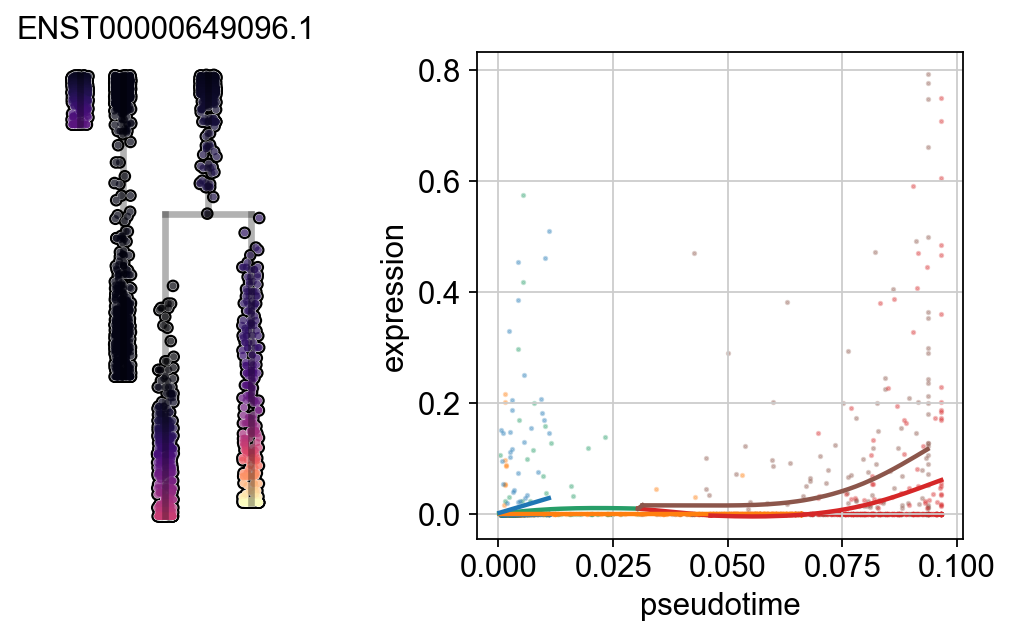

In [56]:
sc.set_figure_params(figsize=(1,3))

gene = adata.var[adata.var["gene"]=="KIF1A"].index[0]

scf.pl.single_trend(adata, feature = gene, basis="dendro",cmap_cells="magma",
                    frameon=False,add_outline=True)

#adata.var[adata.var["gene"]=="MYCN"].index.tolist()

In [130]:
hvg_iso = adata.var.loc[
    adata.var["highly_variable"],
    "transcript"
].unique().tolist()
len(hvg_genes)

408

In [133]:
hvg_genes = adata.var.loc[
    adata.var["highly_variable"],
    "gene"
].unique().tolist()
len(hvg_genes)

277

In [51]:
hvg_genes

['KIF1B-202',
 'CDC42-208',
 'STMN1-225',
 'STMN1-215',
 'C1orf216-204',
 'CDCA8-201',
 'PPT1-219',
 'RIMS3-205',
 'ENST00000829238',
 'NFIA-215',
 'SH3GLB1-201',
 'ENST00000754070',
 'ENST00000762830',
 'TXNIP-204',
 'TXNIP-207',
 'BNIPL-207',
 'MLLT11-202',
 'MLLT11-206',
 'MLLT11-203',
 'ADAR-221',
 'DEDD-252',
 'C1orf226-202',
 'RGS4-202',
 'RGS4-203',
 'RGS5-201',
 'RGS5-213',
 'RGS5-202',
 'ASTN1-206',
 'ATP2B4-206',
 'ENST00000652106',
 'OR2M3-202',
 'NBAS-206',
 'NBAS-208',
 'NBAS-209',
 'NBAS-212',
 'NBAS-215',
 'NBAS-217',
 'NBAS-218',
 'NBAS-219',
 'NBAS-220',
 'DDX1-213',
 'DDX1-204',
 'DDX1-228',
 'DDX1-217',
 'LINC01804-203',
 'MYCNOS-205',
 'MYCNOS-202',
 'GACAT3-208',
 'ENST00000777439',
 'GEN1-202',
 'OSR1-202',
 'WDR35-201',
 'KIF3C-208',
 'HADHB-217',
 'PPP1CB-207',
 'PPP1CB-224',
 'PPP1CB-227',
 'PPP1CB-202',
 'PPP1CB-218',
 'YPEL5-212',
 'ENST00000414796',
 'CALM2-209',
 'SPTBN1-208',
 'SPTBN1-209',
 'SPTBN1-211',
 'EML6-201',
 'RTN4-202',
 'RTN4-207',
 'MTIF2-223'

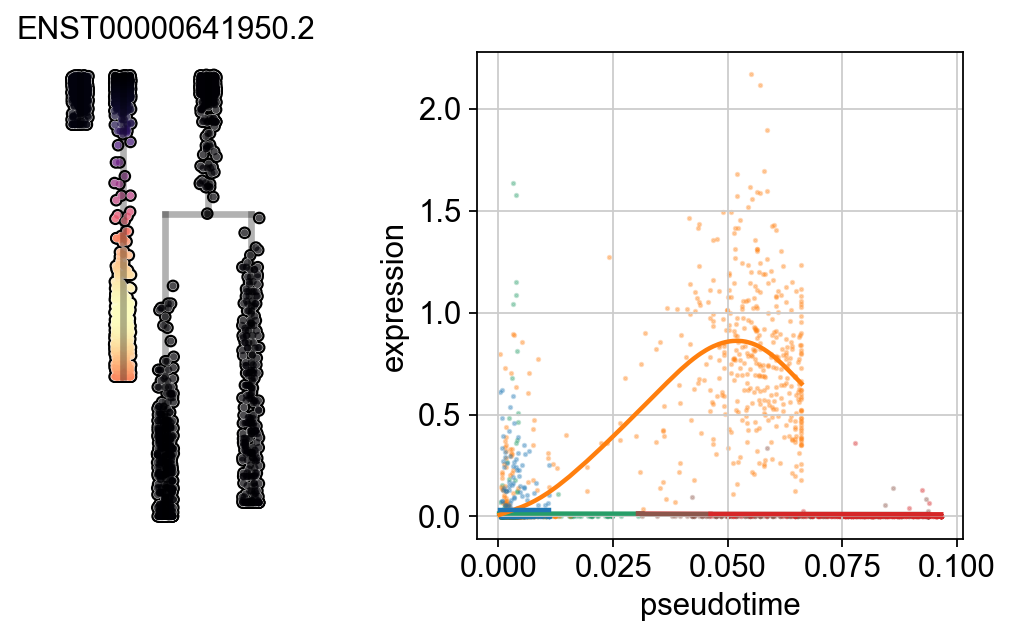

In [101]:
sc.set_figure_params(figsize=(1,3))

gene = adata.var[adata.var["transcript"]=="MYCNOS-205"].index[0]

scf.pl.single_trend(adata, feature = gene, basis="dendro",cmap_cells="magma",
                    frameon=False,add_outline=True)

In [102]:
hvg_ID = adata.var_names[adata.var["highly_variable"]==True]

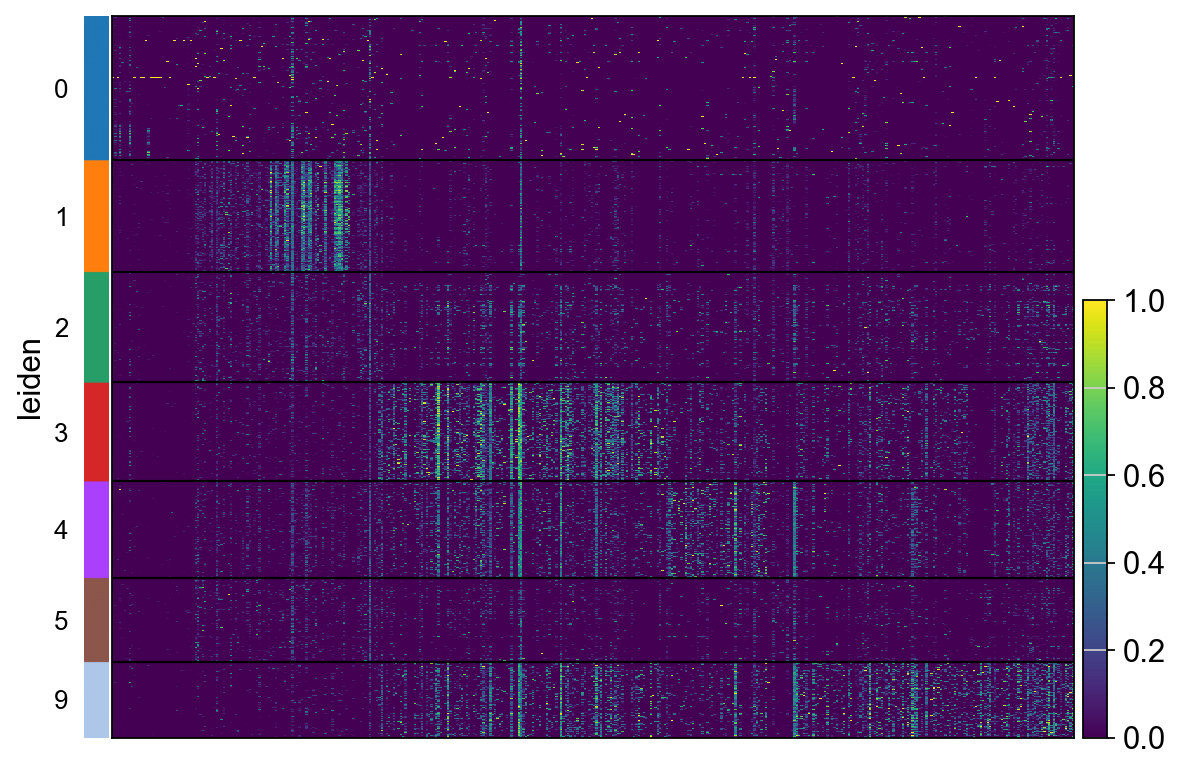

In [103]:
import numpy as np
import pandas as pd
import scanpy as sc

# 1. expression moyenne par cluster
expr = pd.DataFrame(
    adata[:, hvg_ID].X.toarray() if hasattr(adata[:, hvg_ID].X, "toarray") else adata[:, hvg_ID].X,
    columns=hvg_ID,
    index=adata.obs["leiden"]
).groupby(level=0).mean()

# 2. cluster où chaque gène est le plus exprimé
dominant_cluster = expr.idxmax(axis=0)

# 3. tri des gènes selon cluster dominant
ordered_genes = dominant_cluster.sort_values().index.tolist()

# 4. heatmap
sc.pl.heatmap(
    adata,
    var_names=ordered_genes,
    groupby="leiden",
    standard_scale="var",
    cmap="viridis"
)

In [106]:
adata.obs.seg

L9_SS2_17_284     3
B11_SS2_17_284    3
E23_SS2_17_284    3
E24_SS2_17_284    3
M14_SS2_17_284    3
                 ..
K12_SS2_19_106    1
E3_SS2_19_106     2
B24_SS2_19_106    4
H19_SS2_19_106    4
M22_SS2_19_106    2
Name: seg, Length: 2682, dtype: category
Categories (5, object): ['1', '2', '3', '4', '5']

In [125]:
list_test = ["MYCN","ALK","MTND2P28"]

In [135]:
multi_iso = []

for gene in hvg_genes:
    n_iso = len(adata.var[adata.var["gene"]==gene])
    #print(f"n_iso:{n_iso}")
    if n_iso > 1:
        multi_iso.append(gene)

len(multi_iso)

157

In [150]:
DIU_data = adata[:,adata.var["gene"].isin(multi_iso)==True]

In [342]:
DIU_data.write(f"/home/matei/data/DIU_data.h5ad")

In [151]:
DIU_data.var["gene"].unique()

['KIF1B', 'CDC42', 'STMN1', 'RIMS3', 'NFIA', ..., 'XIST', 'RBM41', 'ARHGAP36', 'PHF6', 'FGF13']
Length: 157
Categories (157, object): ['ACBD5', 'ACTB', 'ADAMTS2', 'ADAR', ..., 'ZNF121', 'ZNF507', 'ZNF573', 'ZNF792']

In [173]:
DIU_data.var["gene"].unique().tolist()

['KIF1B',
 'CDC42',
 'STMN1',
 'RIMS3',
 'NFIA',
 'SH3GLB1',
 'TXNIP',
 'MLLT11',
 'ADAR',
 'RGS4',
 'RGS5',
 'ASTN1',
 'ATP2B4',
 'NBAS',
 'DDX1',
 'LINC01804',
 'MYCNOS',
 'GACAT3',
 'ENSG00000236989',
 'GEN1',
 'KIF3C',
 'PPP1CB',
 'YPEL5',
 'CALM2',
 'SPTBN1',
 'EML6',
 'RTN4',
 'MAT2A',
 'SF3B1',
 'MAP2',
 'SCG2',
 'LRRFIP1',
 'ALCAM',
 'CIP2A',
 'ZBTB20',
 'PDCD10',
 'CRMP1',
 'MRFAP1',
 'FAM200B',
 'PCDH7',
 'UCHL1',
 'CCSER1',
 'ANK2',
 'HAND2-AS1',
 'MAP1B',
 'MATR3',
 'DPYSL3',
 'ADAMTS2',
 'C6orf62',
 'HSP90AB1',
 'DST',
 'SERINC1',
 'AKAP12',
 'ACTB',
 'GLCCI1',
 'NXPH1',
 'HYCC1',
 'NPY',
 'CREB5',
 'DLX6-AS1',
 'LRRN3',
 'UBE2H',
 'SSBP1',
 'TMEM176B',
 'ATP6V1B2',
 'NEFL',
 'DPYSL2',
 'CLU',
 'SARAF',
 'SFRP1',
 'STMN2',
 'TMOD1',
 'DBH',
 'ACBD5',
 'PSAP',
 'INA',
 'SLC18A2',
 'TH',
 'EIF4G2',
 'CD44',
 'BSCL2',
 'NEAT1',
 'MALAT1',
 'CCND1',
 'CADM1',
 'SCN3B',
 'GAPDH',
 'ENO2',
 'NELL2',
 'ANO6',
 'TUBA1A',
 'TMBIM6',
 'ATP5F1B',
 'CPSF6',
 'SYT1',
 'RIMBP2',
 'HSPH1

In [162]:
DIU_data.var[DIU_data.var["gene"]=="KIF1B"].index.tolist()

['ENST00000858327.1',
 'ENST00000696501.1',
 'ENST00000377081.5',
 'ENST00000620295.2',
 'ENST00000622724.3']

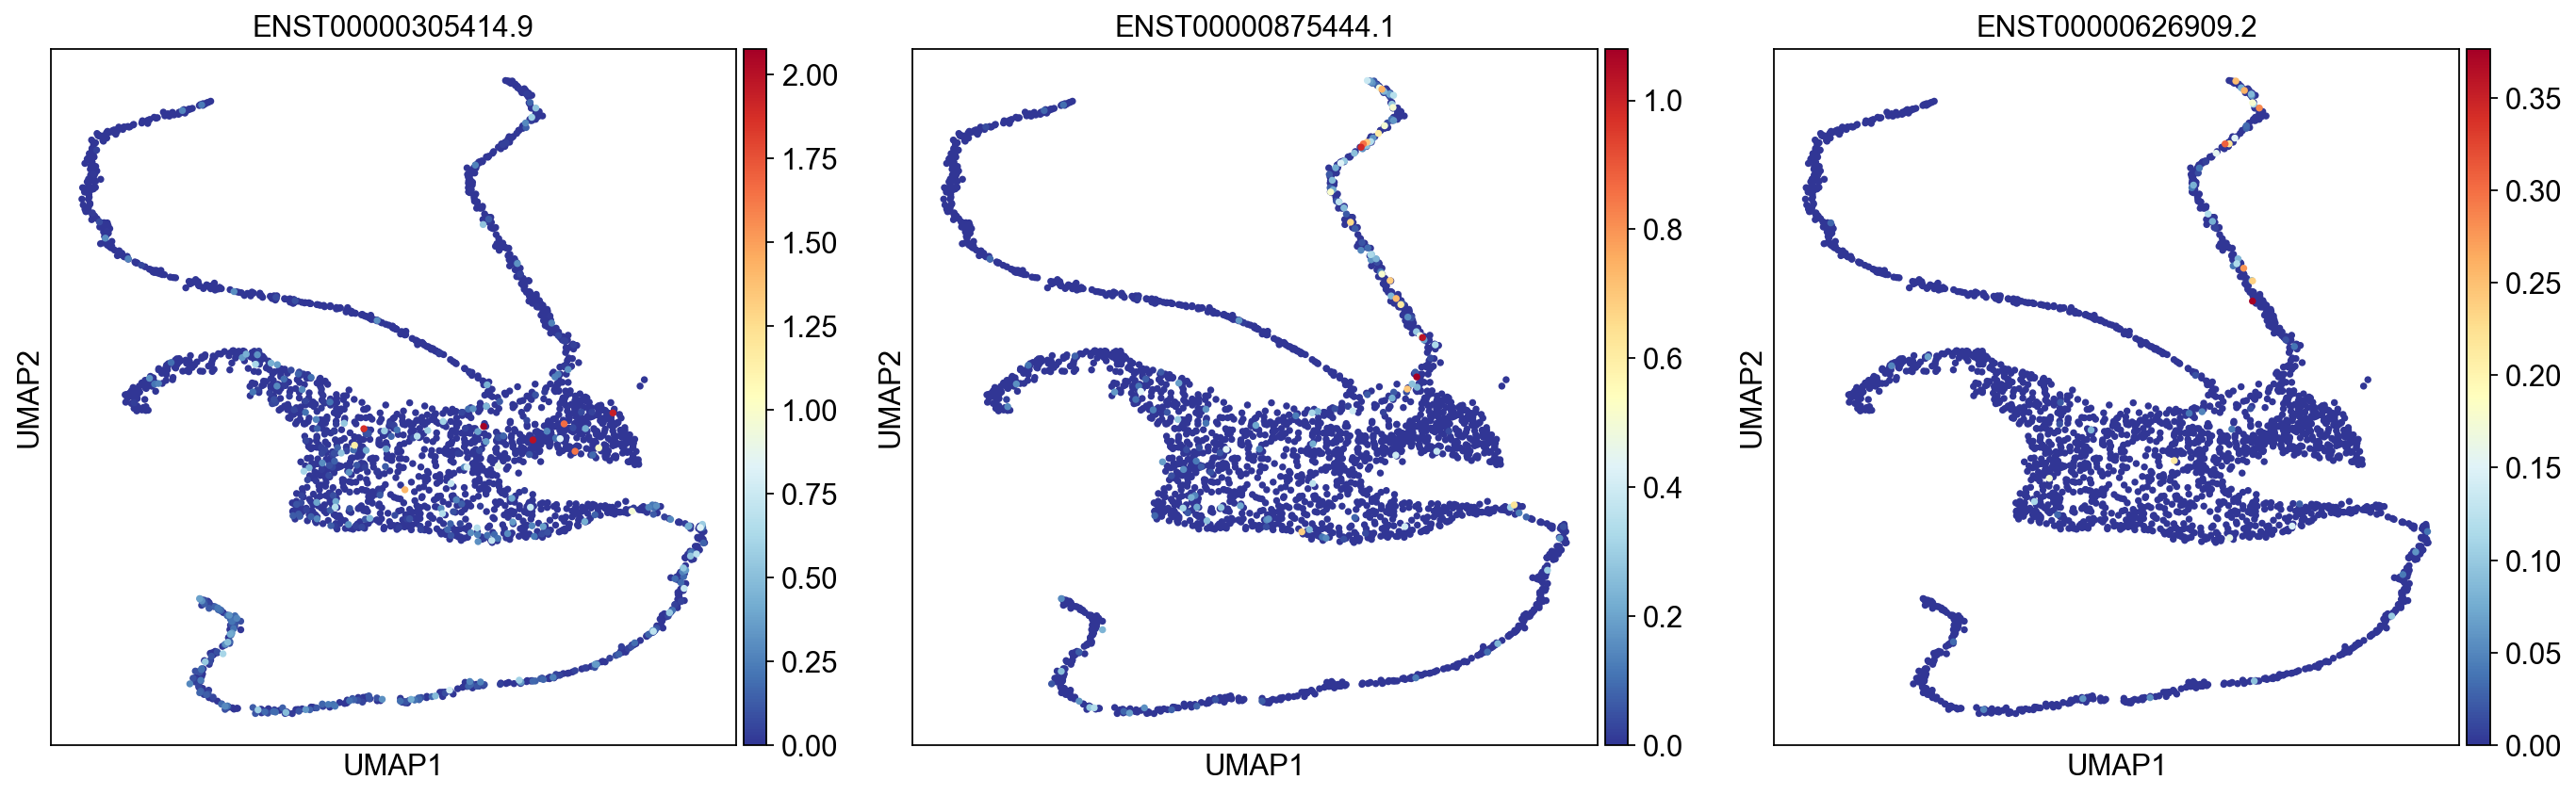

In [341]:
sc.set_figure_params(figsize=(6,6))

sc.pl.umap(DIU_data,
           color = DIU_data.var[DIU_data.var["gene"]=="FGF13"].index.tolist(),
           cmap="RdYlBu_r",
                     )

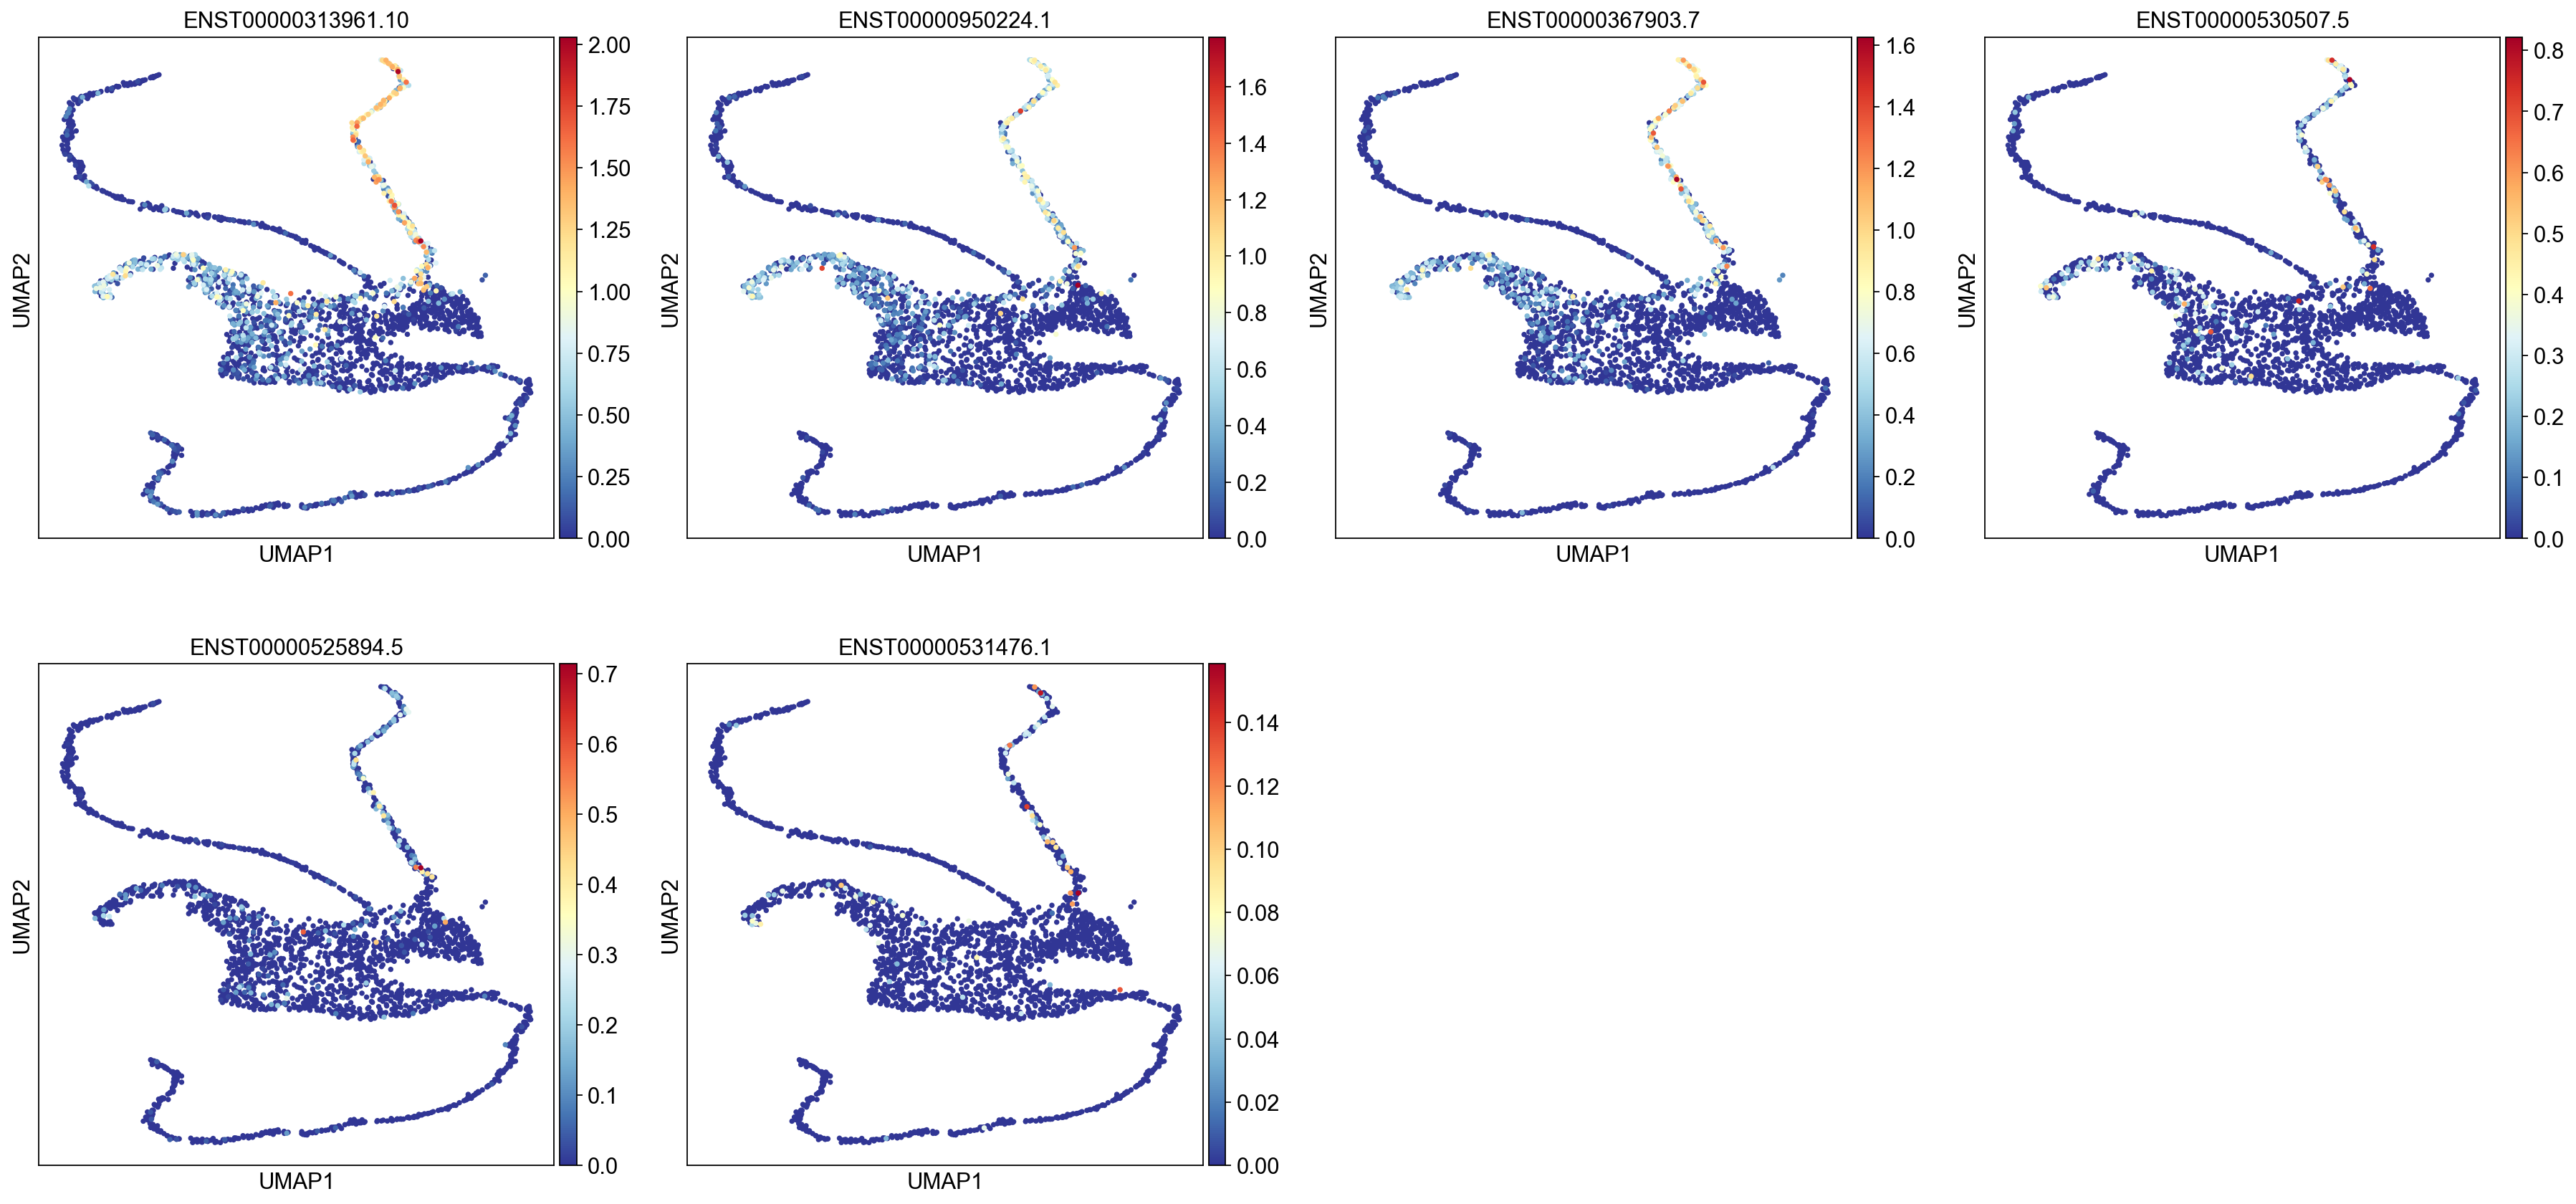

In [169]:
sc.set_figure_params(figsize=(6,6))
sc.pl.umap(DIU_data,
           color = DIU_data.var[DIU_data.var["gene"]=="RGS5"].index.tolist(),
           cmap="RdYlBu_r"
          )

In [60]:
sc.tl.rank_genes_groups(adata, groupby="seg", method="wilcoxon")

In [83]:
sc.get.rank_genes_groups_df(adata, group="1",gene_symbols = "transcript").head(15)

,names,scores,logfoldchanges,pvals,pvals_adj,transcript
0,ENST00000674361.1,19.433369,1.486277,4.030274e-84,7.655932e-80,XACT-203
1,ENST00000970013.1,16.111811,1.043797,2.107615e-58,2.119573e-54,NBPF15-268
2,ENST00000820793.1,15.471736,0.815989,5.383513e-54,4.601948e-50,FAM66B-214
3,ENST00000436967.5,14.870229,7.051519,5.143708e-50,3.823441e-46,LINC01804-201
4,ENST00000700070.1,14.732326,5.103886,3.997113e-49,2.907933e-45,NBAS-217
5,ENST00000677649.1,14.623299,4.695243,1.994952e-48,1.392106e-44,DDX1-217
6,ENST00000641950.2,14.449042,4.384487,2.541956e-47,1.639941e-43,MYCNOS-205
7,ENST00000492352.5,14.349481,5.513820,1.073376e-46,6.553897e-43,LINC01804-203
8,ENST00000700073.1,14.330230,5.641073,1.416514e-46,8.497322e-43,NBAS-220
9,ENST00000790530.1,14.267342,4.877595,3.496534e-46,2.061321e-42,ENST00000790530


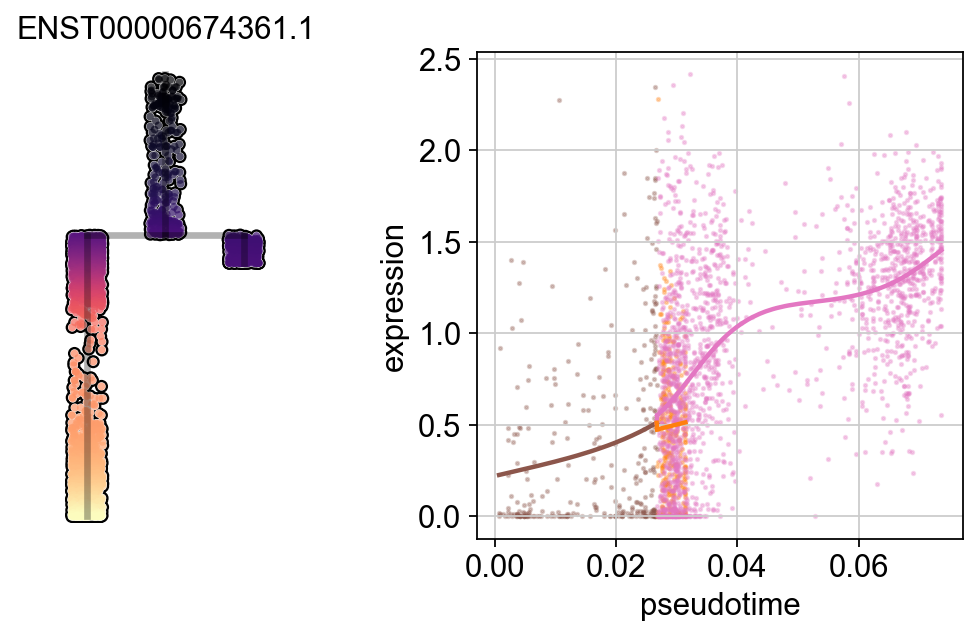

In [67]:
gene = adata.var[adata.var["transcript"]=="XACT-203"].index[0]

scf.pl.single_trend(adata, feature = gene, basis="dendro",cmap_cells="magma",
                    frameon=False,add_outline=True)

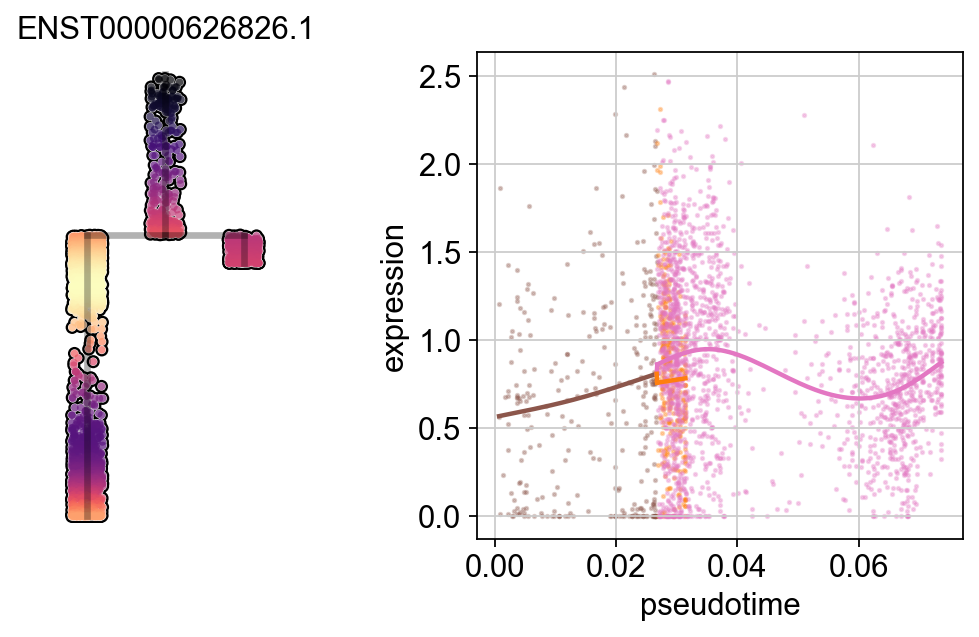

In [88]:
gene = adata.var[adata.var["gene"]=="HELLPAR"].index[0]

scf.pl.single_trend(adata, feature = gene, basis="dendro",cmap_cells="magma",
                    frameon=False,add_outline=True)

In [49]:
#[adata.uns["graph"]["pp_info"].time<max_t].index

<function list.index(value, start=0, stop=9223372036854775807, /)>

In [57]:
np.argwhere(adata.uns["graph"]["pp_info"].loc[adata.uns["graph"]["pp_info"].time<max_t].index==12)[0][0]

np.int64(8)

In [ ]:
newroot=np.argwhere(adata.uns["graph"]["pp_info"].loc[adata.uns["graph"]["pp_info"].time<max_t].index==410)[0][0]
adata.obsm["X_R"]=adata.obsm["X_R"][:,adata.uns["graph"]["pp_info"].time<max_t]
adata.uns["graph"]["B"]=adata.uns["graph"]["B"][adata.uns["graph"]["pp_info"].time<max_t,:][:,adata.uns["graph"]["pp_info"].time<max_t]
adata.uns["graph"]["F"]=adata.uns["graph"]["F"][:,adata.uns["graph"]["pp_info"].time<max_t]

In [30]:
max_t=adata[adata.obs.seg.isin(["3"])].obs.t.max()

In [31]:
adata=adata[adata.obs.t<max_t]

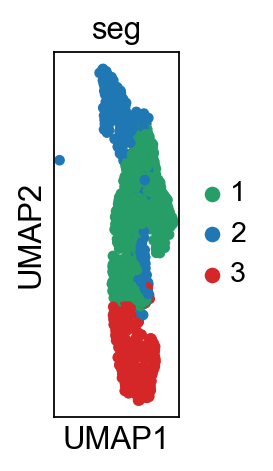

In [47]:
sc.pl.umap(adata,color="seg")

In [35]:
newroot=np.argwhere(adata.uns["graph"]["pp_info"].loc[adata.uns["graph"]["pp_info"].time<max_t].index==410)[0][0]
adata.obsm["X_R"]=adata.obsm["X_R"][:,adata.uns["graph"]["pp_info"].time<max_t]
adata.uns["graph"]["B"]=adata.uns["graph"]["B"][adata.uns["graph"]["pp_info"].time<max_t,:][:,adata.uns["graph"]["pp_info"].time<max_t]
adata.uns["graph"]["F"]=adata.uns["graph"]["F"][:,adata.uns["graph"]["pp_info"].time<max_t]

IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
scf.tl.root(adata,newroot)

In [38]:
scf.tl.pseudotime(adata)

projecting cells onto the principal graph


/home/matei/anaconda3/envs/neuroblastoma/lib/python3.14/site-packages/scFates/tools/pseudotime.py:118: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[df_summary.columns] = df_summary


    finished (0:00:30) --> added
    .obs['edge'] assigned edge.
    .obs['t'] pseudotime value.
    .obs['seg'] segment of the tree assigned.
    .obs['milestones'] milestone assigned.
    .uns['pseudotime_list'] list of cell projection from all mappings.


## Defining a Gene score

In [ ]:
sc.pl.umap(adata,color=adata.var[adata.var.gene=="MYCN"].index.tolist(),title=adata.var.transcript[adata.var.gene=="MYCN"].tolist())

In [ ]:
sc.pl.umap(adata,color=adata.var[adata.var.gene=="NBAS"].index.tolist(),title=adata.var.transcript[adata.var.gene=="NBAS"].tolist())

In [ ]:
sc.pl.umap(adata,color=adata.var[adata.var.gene=="LINC01804"].index.tolist(),title=adata.var.transcript[adata.var.gene=="LINC01804"].tolist())

In [ ]:
NB_score_list = []
NB_transcripts = ["MYCN-204","NBAS-220","LINC01804-201"]
for cell in adata.obs_names:
    transcripts = adata.var[adata.var.transcript.isin(NB_transcripts)].index.tolist()
    value = adata[[cell],transcripts].X.sum() 
    NB_score_list.append(value)
   
adata.obs["NB_score"]=NB_score_list

In [ ]:
sc.pl.umap(adata,color="NB_score")